In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


In [189]:
!pip install pyforest

In [3]:
import os
os.getcwd()

'C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking'

In [190]:
#Load the customer tip dataset and print the first five observations
cus=pd.read_csv("C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\customer_tip.csv")
cus.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [9]:
#1. Make a list of categorical and numerical variables in the data
categorical_cus= [i for i in cus.select_dtypes(include=object)]
print("categorical_cus",categorical_cus)
numerical_cus=  [j for j in cus.select_dtypes(np.number)]
print("numerical_cus",numerical_cus)

categorical_cus ['sex', 'smoker', 'day', 'time']
numerical_cus ['total_bill', 'tip', 'size']


In [11]:
#2. Compute the average bill amount for each day
avgbill=cus.groupby(['day'])['total_bill'].mean()
avgbill

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [15]:
#3. Which gender is more generous in giving the tip?
custip=cus.groupby(['sex'])['tip'].mean()
custip

sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64

In [ ]:
From the above output, we can infer that males are giving slightly higher tip amount than females.

In [19]:
#4.4. According to the data, were there more customers for dinner or lunch?
cus.time.mode()

0    Dinner
Name: time, dtype: object

In [ ]:
The output shows that there were more customers for dinner.

In [21]:
#5. Based on the statistical summary, comment on the variable 'tip'
custip=cus['tip'].describe()
custip

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

In [ ]:
#6. Find the busiest day in terms of the orders

In [22]:
cus.day.value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [ ]:
The output shows that Saturday is the busiest day, as the count for orders is highest.

In [193]:
#7. Is the variable 'total_bill' skewed? If yes, identify the type of skewness. Support your answer with a plot
cusskew=cus['total_bill'].skew()
cusskew

1.1332130376158205

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_20416\837504581.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=cus.total_bill,kde=True)


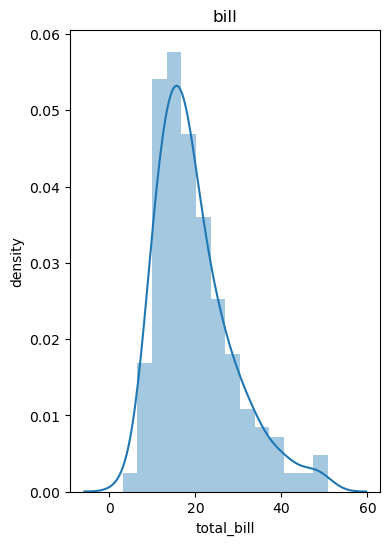

In [27]:
plt.figure(figsize=(4,6))
sns.distplot(a=cus.total_bill,kde=True)
plt.xlabel("total_bill")
plt.ylabel("density")
plt.title("bill")
plt.show()

In [ ]:
The value for skewness is positive. Let us plot a distribution of the variable and check the skewness.
Both the coefficient of skewness and density plot shows the positive distribution of total bill amount.

In [ ]:
#8. Is the tip amount dependent on the total bill?

In [30]:
cus[['total_bill','tip']].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


In [194]:
cus[['total_bill','tip']].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


In [ ]:
There is a moderate positive correlation between the tip amount and the total bill. We may say that the customers tend to give tip based on their order bill amount.

In [ ]:
#9. What is the value under which 20% of the total bill would lie?

In [32]:
q=np.quantile(a=cus.total_bill,q=0.20)
q

12.636

In [ ]:
The output shows that 20% of the orders have a total bill amount less than 12.636 US dollars.

In [39]:
#10. Retrieve the orders where the bill amount is more than 2 standard deviation away from the average bill
from scipy.stats import zscore
cus['zscr']=zscore(cus.total_bill)

cus[cus['zscr'] > 2]






,total_bill,tip,sex,smoker,day,time,size,zscr
23,39.42,7.58,Male,No,Sat,Dinner,4,2.210010
56,38.01,3.00,Male,Yes,Sat,Dinner,4,2.051300
59,48.27,6.73,Male,No,Sat,Dinner,4,3.206166
95,40.17,4.73,Male,Yes,Fri,Dinner,4,2.294430
102,44.30,2.50,Female,Yes,Sat,Dinner,3,2.759302
112,38.07,4.00,Male,No,Sun,Dinner,3,2.058054
142,41.19,5.00,Male,No,Thur,Lunch,5,2.409241
156,48.17,5.00,Male,No,Sun,Dinner,6,3.194910
170,50.81,10.00,Male,Yes,Sat,Dinner,3,3.492068
182,45.35,3.50,Male,Yes,Sun,Dinner,3,2.877490


In [ ]:
The output dataframe returns 14 orders for which the z-score is greater than 2

In [199]:
from scipy.stats import zscore
cus['zsc']=zscore(cus.total_bill)
cus[cus['zsc'] > 2]

,total_bill,tip,sex,smoker,day,time,size,zsc
23,39.42,7.58,Male,No,Sat,Dinner,4,2.210010
56,38.01,3.00,Male,Yes,Sat,Dinner,4,2.051300
59,48.27,6.73,Male,No,Sat,Dinner,4,3.206166
95,40.17,4.73,Male,Yes,Fri,Dinner,4,2.294430
102,44.30,2.50,Female,Yes,Sat,Dinner,3,2.759302
112,38.07,4.00,Male,No,Sun,Dinner,3,2.058054
142,41.19,5.00,Male,No,Thur,Lunch,5,2.409241
156,48.17,5.00,Male,No,Sun,Dinner,6,3.194910
170,50.81,10.00,Male,Yes,Sat,Dinner,3,3.492068
182,45.35,3.50,Male,Yes,Sun,Dinner,3,2.877490


### Binomial distribution

In [ ]:
#binomial 
n=3
p=0.5
# P(x=0)=? to P(x=3)=?


In [203]:
import scipy.stats as st
x=np.arange(0,4)
n=3
p=0.5
print("probability mass function")
print(st.binom.pmf(x,n,p))
print("cummulative distribution function")
print(st.binom.cdf(x,n,p))
print("survival function")
print(st.binom.sf(x,n,p))
print( "st.binom.cdf + st.binom.sf",(st.binom.cdf(x,n,p) + st.binom.sf(x,n,p)))

probability mass function
[0.125 0.375 0.375 0.125]
cummulative distribution function
[0.125 0.5   0.875 1.   ]
survival function
[0.875 0.5   0.125 0.   ]
st.binom.cdf + st.binom.sf [1. 1. 1. 1.]


In [200]:
x=np.arange(0,4)
n=3
p=0.5
# P(x=0)=? to P(x=3)=?
st.binom.ppf

In [ ]:
p= prob of purchase =0.3
n=40
P(x=12)=?

In [14]:
# P(x=12)=?
x=np.arange(0,13)
n=40
p=0.3
st.binom.pmf(12,n,p)

<IPython.core.display.Javascript object>

0.13657382060056145

In [16]:
# what is the prob of min 15 customers purchase the product?
x=np.arange(15,41)
n=40
p=0.3
st.binom.pmf(x,n,p).sum()

<IPython.core.display.Javascript object>

0.19255175473517608

In [206]:
x=np.arange(15,41)
n=40
p=0.3
st.binom.pmf(x,n,p).sum()

0.19255175473517608

In [19]:
1-st.binom.cdf(14,n,p)

0.1925517547351756

In [20]:
st.binom.sf(14,n,p)

0.19255175473517566

In [ ]:
#what is the prob of 15-20 customers purcahse the product?

In [25]:
st.binom.cdf(20,n,p) - st.binom.cdf(14,n,p)

0.190132394838042

In [24]:
st.binom.sf(14,n,p) - st.binom.sf(20,n,p)

0.19013239483804206

In [27]:
1 - (st.binom.cdf(14,n,p) + st.binom.sf(20,n,p))

0.190132394838042

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<BarContainer object of 41 artists>

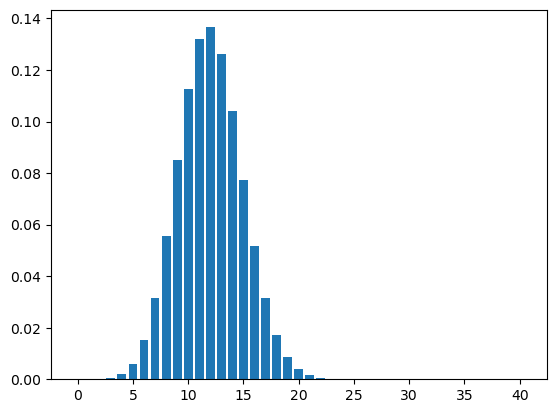

In [31]:
x=np.arange(0,41) #discrete random number
pmf=st.binom.pmf(x,n,p)
plt.bar(x,pmf)


<BarContainer object of 41 artists>

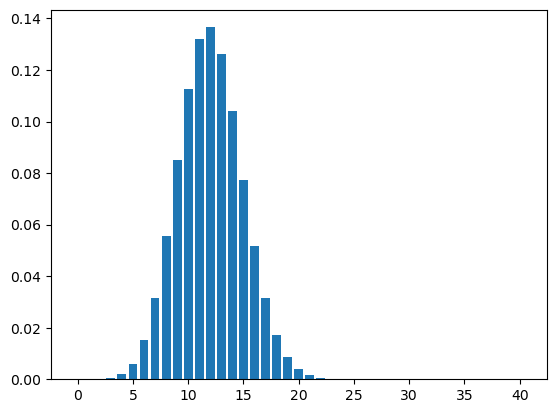

In [208]:
x=np.arange(0,41)
pmf=st.binom.pmf(x,n,p)
plt.bar(x,pmf)

<IPython.core.display.Javascript object>

<BarContainer object of 41 artists>

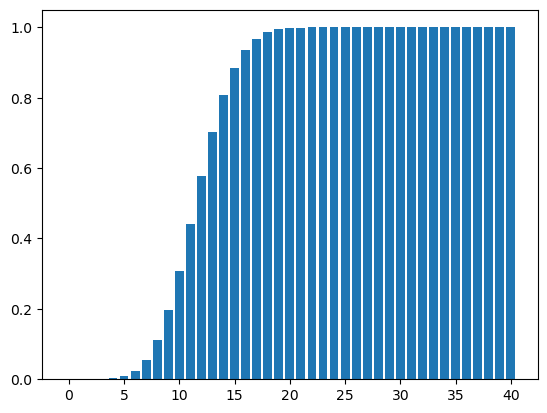

In [32]:
cdf = st.binom.cdf(x,n,p)
plt.bar(x,cdf)

<IPython.core.display.Javascript object>

<BarContainer object of 41 artists>

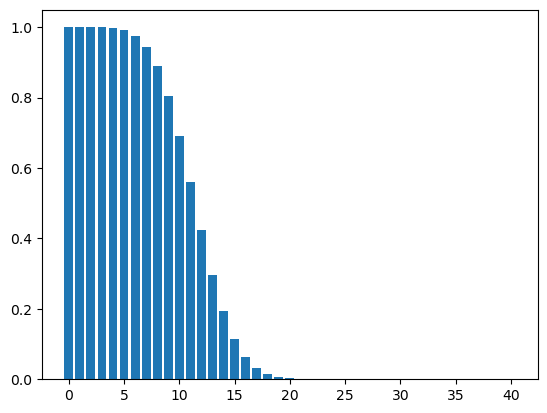

In [33]:
sf = st.binom.sf(x,n,p)
plt.bar(x,sf)

#### normal distribution for continous random variable

In [ ]:
mean age= 35
sd of age= 5 
i) P(X>=40)=?
ii) P(30<=x<=50)=?
iii) P(X<=40)=?

In [37]:
# P(x>=40)=?
mu=35
sigma=5
st.norm.sf(40,mu,sigma)

0.15865525393145707

In [38]:
mu=35
sigma=5
# P(x>40)=?
print("P(x>40)",st.norm.sf(40,mu,sigma))
# P(30<=X<=50) 
print("P(30<=X<=50) using cdf",st.norm.cdf(50,mu,sigma) - st.norm.cdf(30,mu,sigma))
print(" P(30<=X<=50) using sf",st.norm.sf(30,mu,sigma) - st.norm.sf(50,mu,sigma))
print("using cdf and sf together",1-(st.norm.cdf(30,mu,sigma) + st.norm.sf(50,mu,sigma) ))
# P(25<=X<=45)
print("\n P(25<=X<=45) using cdf",st.norm.cdf(45,mu,sigma) - st.norm.cdf(25,mu,sigma))
print("\n P(25<=X<=45) using sf",st.norm.sf(25,mu,sigma) - st.norm.sf(45,mu,sigma))
print("\n P(25<=X<=45) using cdf and sf", 1 - (st.norm.cdf(25,mu,sigma) + st.norm.sf(45,mu,sigma)))

P(x>40) 0.15865525393145707
P(30<=X<=50) using cdf 0.8399948480369128
 P(30<=X<=50) using sf 0.8399948480369128
using cdf and sf together 0.8399948480369128

 P(25<=X<=45) using cdf 0.9544997361036416

 P(25<=X<=45) using sf 0.9544997361036416

 P(25<=X<=45) using cdf and sf 0.9544997361036416


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

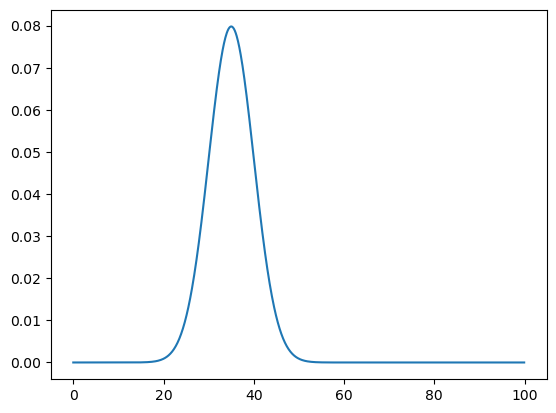

In [40]:
x1=np.arange(0,100,0.1)
pdf=st.norm.pdf(x1,mu,sigma)
plt.plot(x1,pdf)

<IPython.core.display.Javascript object>

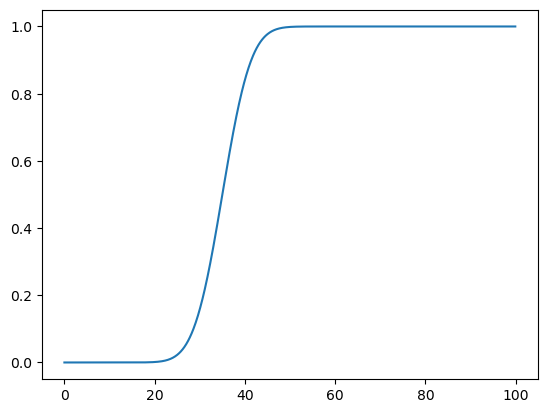

In [41]:
cdf=st.norm.cdf(x1,mu,sigma)
plt.plot(x1,cdf)

<IPython.core.display.Javascript object>

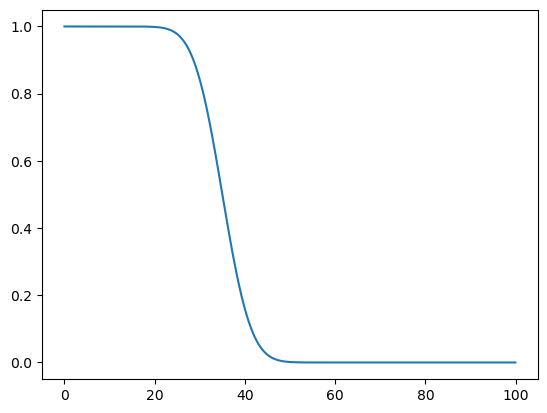

In [42]:
sf=st.norm.sf(x1,mu,sigma)
plt.plot(x1,sf)

In [43]:
# P(30<=X<=40)  ## using cdf function : mu +-1 sigma
st.norm.cdf(40,mu,sigma)-st.norm.cdf(30,mu,sigma)

0.6826894921370859

In [45]:
# P(25<=X<=45)  ## using cdf function : mu +-2 sigma
st.norm.cdf(45,mu,sigma)-st.norm.cdf(25,mu,sigma)

0.9544997361036416

In [46]:
# P(20<=X<=50)  ## using cdf function : mu +-3 sigma
st.norm.cdf(50,mu,sigma)-st.norm.cdf(20,mu,sigma)

0.9973002039367398

#### Standard Normal Distribution

In [209]:
# P(-1<=Z<=1)  ## using cdf function : Z = +-1
st.norm.cdf(1)-st.norm.cdf(-1)

0.6826894921370859

In [49]:
# P(-2<=Z<=2)  ## using cdf function : Z = +-2
st.norm.cdf(2)-st.norm.cdf(-2)

0.9544997361036416

In [50]:
# P(-3<=Z<=3)  ## using cdf function : Z = +-3
st.norm.cdf(3)-st.norm.cdf(-3)


0.9973002039367398

In [51]:
# P(-4.65<=Z<=4.65)  ## using cdf function : Z = +-4.65
st.norm.cdf(4.65)-st.norm.cdf(-4.65)

0.9999966806497114

In [52]:
## what is the min  age of learners where 60% of them are         min---isf()
## having that min age?
sf=0.6
mu=35
sigma=5
st.norm.isf(sf, mu,sigma)

33.733264484321005

In [53]:
## what is the max age of learners where 75% of them are         max---ppf()
## having that max age?
cdf=0.75
mu=35
sigma=5
st.norm.ppf(cdf, mu,sigma)

38.37244875098041

#### random sampling 

In [ ]:
1. An ice-cream manufacturer wants to study the sales of ice-creams to decide the production policies of the company. He collects the data for the number of ice-creams sold in a month from the 30 franchise. Randomly select the sales of 10 franchise for the study.
data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]

In [3]:
#random sampling without replacement
random.seed(100)
mdata=[21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]
sample_without_replacement = random.sample(mdata,k=10)
print("sample_without_replacement",sample_without_replacement)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sample_without_replacement [73, 34, 14, 92, 20, 82, 80, 13, 88, 40]


In [8]:
#random sampling with replacement
random.seed(100)
mdata=[21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]
sample_with_replacement = random.choices(mdata,k=10)
print("sample_with_replacement",sample_with_replacement )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sample_with_replacement [73, 88, 10, 23, 23, 88, 92, 18, 62, 88]


#### Stratified Random Sampling

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
mydf=sns.load_dataset("tips")

<IPython.core.display.Javascript object>

In [12]:
mydf.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


In [14]:
mydf.time.value_counts(normalize=True)*100

time
Dinner    72.131148
Lunch     27.868852
Name: proportion, dtype: float64

In [16]:
mydf.drop('time',axis=1)

,total_bill,tip,sex,smoker,day,size
0,16.99,1.01,Female,No,Sun,2
1,10.34,1.66,Male,No,Sun,3
2,21.01,3.50,Male,No,Sun,3
3,23.68,3.31,Male,No,Sun,2
4,24.59,3.61,Female,No,Sun,4
...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,3
240,27.18,2.00,Female,Yes,Sat,2
241,22.67,2.00,Male,Yes,Sat,2
242,17.82,1.75,Male,No,Sat,2


In [17]:
x=mydf
y=mydf.time

In [18]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,  stratify=mydf.time)

In [22]:
y_train.value_counts(normalize=True)*100


time
Dinner    71.428571
Lunch     28.571429
Name: proportion, dtype: float64

In [23]:
y_test.value_counts(normalize=True)*100

time
Dinner    72.307692
Lunch     27.692308
Name: proportion, dtype: float64

In [26]:
print(y_train.shape  ,y_test.shape)

(49,) (195,)


In [27]:
import scipy.stats as st 

In [33]:
population1= st.norm.rvs(10,0.5,10000)

In [34]:
len(population1)

10000

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_13468\4265792527.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(population1)


<Axes: ylabel='Density'>

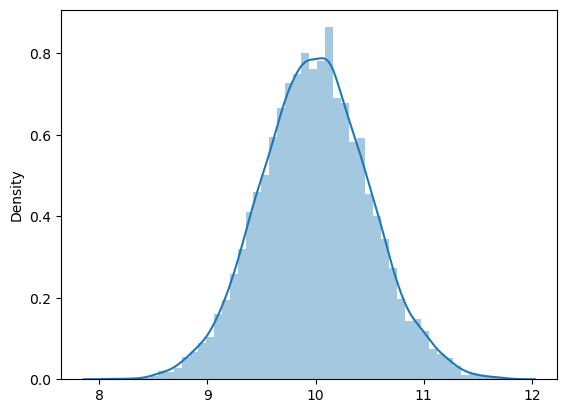

In [35]:
sns.distplot(population1)

In [41]:
population2=st.skewnorm.rvs(-10,0.5,size=10000)
len(population2)

10000

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_13468\2738959746.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(population2)


<Axes: ylabel='Density'>

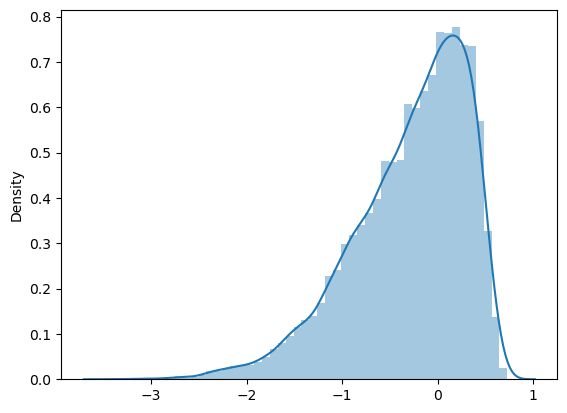

In [42]:
sns.distplot(population2)

In [45]:
population3=st.skewnorm.rvs(10,0.5,size=10000)
len(population3)

10000

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_13468\2823363394.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(population3)


<Axes: ylabel='Density'>

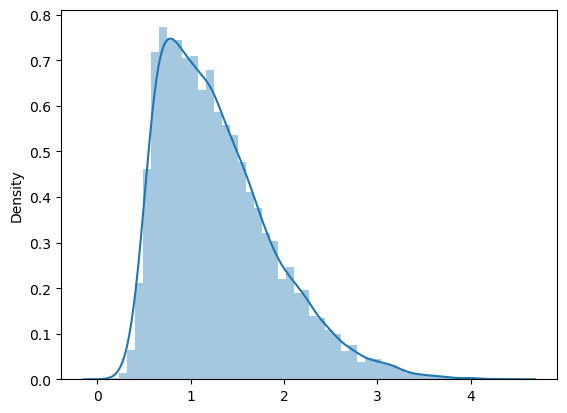

In [46]:
sns.distplot(population3)

In [47]:
sample_means2= [np.mean(random.sample(list(population2),k=50))  for i in range(70)]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
len(sample_means2)

70

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_13468\551123287.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample_means2)


<Axes: ylabel='Density'>

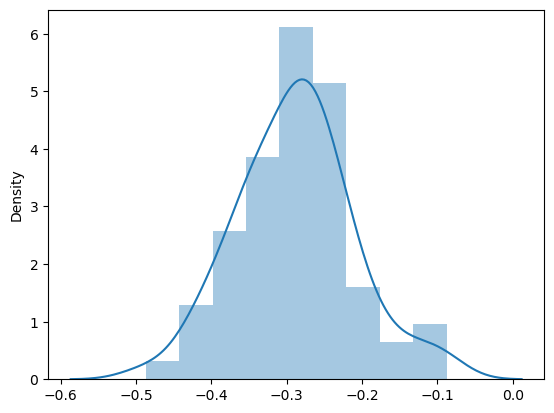

In [49]:
sns.distplot(sample_means2)

In [51]:
mu2=np.mean(population2)
mu2

<IPython.core.display.Javascript object>

-0.28951034223950656

In [52]:
np.mean(sample_means2)

<IPython.core.display.Javascript object>

-0.2892285760362994

In [54]:
std_err=np.std(sample_means2)
std_err

<IPython.core.display.Javascript object>

0.07697894724417592

In [55]:
np.std(population2) / np.sqrt(50)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

0.08564812231213215

In [56]:
sample_means3= [np.mean(random.sample(list(population3),k=50))  for i in range(70) ]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
len(sample_means3)

70

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_13468\3170951997.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample_means3)


<Axes: ylabel='Density'>

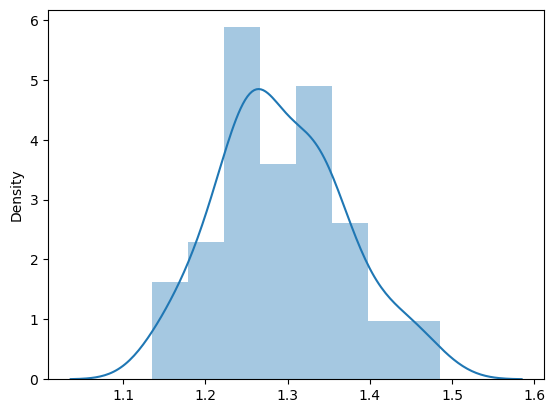

In [58]:
sns.distplot(sample_means3)

In [60]:
mu3=np.mean(population3)
mu3

<IPython.core.display.Javascript object>

1.2950355577952812

In [61]:
np.mean(sample_means3)

<IPython.core.display.Javascript object>

1.29316938489279

In [63]:
std_err3 = np.std(sample_means3)
std_err3

<IPython.core.display.Javascript object>

0.07669977474090932

In [67]:
sigma_byn=np.std(population3) / np.sqrt(50)
sigma_byn

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

0.08594594058652633

In [ ]:
session2 faculty notes

In [ ]:
#1. If the letters of the word AABRAAKAADAABRAA are arranged at random, find the probability that 10 A's come consecutively in the word.

In [1]:
# set the frequency of each letter in the given word
length_of_word = len("AABRAAKAADAABRAA")
No_of_A = 10
No_of_B = 2
No_of_R = 2
No_of_K = 1
No_of_D = 1

In [ ]:
If 10 A's come consecutively in the word, we consider 10 A's as one group ([AAAAAAAAAA]BRKDBR).

Now the total number of letters is 6+1=7.

In [211]:
from math import factorial
# number of words when all A's are together
no_words_with_10A = factorial(7) / (factorial(No_of_B)*factorial(No_of_D)*factorial(No_of_K)*factorial(No_of_R))

# total number of words using the letters of the word "AABRAAKAADAABRAA"
total_words = factorial(length_of_word) /(factorial(No_of_A)*factorial(No_of_B)*factorial(No_of_D)*factorial(No_of_K)
                                          *factorial(No_of_R))

In [212]:
# the required probability is
req_prob = (no_words_with_10A/total_words)
print("The probability that 10 A's come consecutively in the word is", req_prob)

The probability that 10 A's come consecutively in the word is 0.0008741258741258741


In [ ]:
#2.If the letters of the word AABRAAKAADAABRAA are arranged at random, find the probability that 2 B's and 2 R's come together

In [ ]:
We consider 2 B's as 1 group and 2 R's as one group. Thus, the total letters will be 12 + 1 + 1 = 14.

In [213]:
length_of_word = len("AABRAAKAADAABRAA")
No_of_A = 10
No_of_B = 2
No_of_R = 2
No_of_K = 1
No_of_D = 1
# '\' is used to continue the operation in next line
# number of words when 2 B's and 2 R's come together
no_words_with_2B_2R = (factorial(14) / (factorial(No_of_A)*factorial(No_of_D)*factorial(No_of_K))) * \
                      (factorial(4) / (factorial(2)*factorial(2)))

# total number of words using the letters of the word "AABRAAKAADAABRAA"
total_words = factorial(length_of_word) /(factorial(No_of_A)*factorial(No_of_B)*factorial(No_of_D)*factorial(No_of_K) \
                                          *factorial(No_of_R))

In [6]:
# the required probability is
req_prob = (no_words_with_2B_2R/total_words)
print("The probability that 2 B's and 2 R's come together is", req_prob)

The probability that 2 B's and 2 R's come together is 0.1


In [ ]:
#3. A kitchen set contains 10 knives, 3 of which are defective. Two knives are drawn at random with replacement. What is the probability that none of the two knives will be defective?

In [10]:
def combination(n,r):
    result = factorial(n)  / (factorial(r) * factorial(n-r))
    return result
# here 3 knives out of 10 are defective and 7 are not defective
# probability of selecting two non defective knives
probability= ( combination(3,0) * combination(7,2))  / combination(10,2)
print("the probability that none of the two knives will be defective",probability)

the probability that none of the two knives will be defective 0.4666666666666667


In [12]:
#4. The new vaccine is to be tested on patients. 
#There are 5 diabetic patients (have the same type of diabetes),
#9 patients with a similar heart condition and 11 patients with the same liver condition. 
#One patient is randomly chosen. What is the probability that the patient is not diabetic?
total_no_of_patients=25

probability_diabetic_patient = 5 / 25
#non diabetic_person
non_diabetic_patient = 1- probability_diabetic_patient
print("the probability that the patient is not diabetic",non_diabetic_patient)

the probability that the patient is not diabetic 0.8


In [3]:
#5.The odds that a New Yorker picked at random will be either overweight or obese are 14:11. 
#What is the probability that the person is fit (is not overweight or obese)?

A= 14
B=11
# required probability is that the person is fit
# let, A: The person is either overweight or obese
# to find: P(A') = 1 - P(A)
pro= 1 - (A/(A+B))
print("the probability that the person is fit",pro)

the probability that the person is fit 0.43999999999999995


In [ ]:
### Example:

####6.. A random experiment results in an integer outcome from 21 to 30. Consider two events X and Y. 
        X: Occurrence of an even number
        Y: Occurrence of a number divisible by 4
        
#### Calculate the probability that an even number will occur given that the number is divisible by 4.

In [4]:
samplespace = {21,22,23,24,25,26,27,28,29,30}
 #X: Occurrence of an even number
X={22,24,26,28,30}
# Y: Occurrence of a number divisible by 4
Y={24,28}
#find p(X|Y)
probability_x_intersection_Y =2 / 10
probability_y=2 / 10
req_prob = probability_x_intersection_Y  / probability_y
print("the probability that an even number will occur given that the number is divisible by 4",req_prob)

the probability that an even number will occur given that the number is divisible by 4 1.0


In [6]:
#2. A pair of fair dice is rolled. If the product of numbers that appear is 6, find the probability that the second die shows an even number?
#A:product of numbers that appear is 6
A={(1,6),(2,3),(3,2),(6,10)}
no_A = 4
#B:the second die shows an even number
B={
    (1,2),(1,4),(1,6),
    (2,2),(2,4),(2,6),
    (3,2),(3,4),(3,6),
    (4,2),(4,4),(4,6),
    (5,2),(5,4),(5,6),
    (6,2),(6,4),(6,6)
}
no_B=18
#to find p(B|A)
prob_B_intersect_A = 2 / 36
prob_A= 4 /36
req_prob = prob_B_intersect_A  / prob_A
print("the probability that the second die shows an even number",req_prob)

the probability that the second die shows an even number 0.5


### bayes theorm

In [8]:
#1. What is the probability that a girl is chosen given that she likes pink color?

#probability of being a girl
prob_Girl = 120 / 190

#probability of liking pink given a  girl
prob_pink_given_girl = 70 / 120

#probability of liking pink
prob_pink = 80 / 190

#to find p(girl | pink)
prob_girl_given_pink = (prob_Girl * prob_pink_given_girl) / prob_pink
req_prob=np.round(prob_girl_given_pink,2)
print("the probability that a girl is chosen given that she likes pink color",req_prob)

<IPython.core.display.Javascript object>

the probability that a girl is chosen given that she likes pink color 0.88


In [ ]:
#### 2. In an armament production station, the explosion can occur due to short circuit, fault in the machinery, negligence of workers. 
####From experience, the chances of these causes are 0.1, 0.3, 0.6 respectively. The chief engineer feels that an explosion can occur with probability:
        1. 0.3 if there is a short circuit
        2. 0.2 if there is a fault in the machinery
        3. 0.25 if the workers are negligent
#### Given that an explosion has occurred, determine the most likely cause of it?

In [11]:
#probability due to
#short circuit
p_sc= 0.1
#fault in machinery
p_fm=0.3
#negligence of workers
p_nw=0.6

#probalility of exploision occurence given 
#shortcircuit
p_exp_sc = 0.3
#fault in machinery
p_exp_fm = 0.2
#negligence of workers
p_exp_nw = 0.25

#probability of exploison
p_explosion =  (p_sc * p_exp_sc ) + (p_fm * p_exp_fm ) + (p_nw * p_exp_nw ) 

# use Bayes' theorem to calculate the probabilities of cause of explosion given there is an explosion
#shortcircuit
p_sc_given_exp =  (p_sc * p_exp_sc ) / p_explosion
#fault in machinery
p_fm_given_exp=  (p_fm * p_exp_fm ) / p_explosion
#negligence of workers
p_nw_given_exp =  (p_nw * p_exp_nw ) / p_explosion

print("p_sc_given_exp",p_sc_given_exp)
print("p_fm_given_exp",p_fm_given_exp)
print("p_nw_given_exp",p_nw_given_exp)

p_sc_given_exp 0.125
p_fm_given_exp 0.25
p_nw_given_exp 0.625


In [ ]:
# negligence of workers is the main cause for exploision

### takehome session2

In [ ]:
#1.A gift package contains 4 sandalwood perfumes, 6 cherry blossom perfumes and 8 rose perfumes. 
#Two perfumes are randomly selected. Calculate the probability that the sandalwood perfumes are not selected?

In [15]:
from math import factorial
s=4
c=6
r=8
total_perfumes=s+c+r

def combination(n,r):
    result=factorial(n) /( factorial(r) * factorial(n - r))
    return result

#probability of  selecting 2 perfumes which are not sandalwood
two_perfumes = combination((total_perfumes-4),2)

#probability of selecting 2 perfumes
totalways= combination(total_perfumes,2)

#required probability
req_prob = two_perfumes / totalways

print("the probability that the sandalwood perfumes are not selected",np.round(req_prob,2) )

<IPython.core.display.Javascript object>

the probability that the sandalwood perfumes are not selected 0.59


In [ ]:
#2.2. The students' committee had organized a fun gala at their school. Three friends Jack, Mark and Bran have participated in the bucketball game and successfully threw the ball
#in a bucket with the probability 0.65, 0.6, 0.7 respectively. 
#What is the probability that Bran will miss the target given that Mark threw the ball successfully?

In [17]:
p_Jack_threw =0.65
p_Mark_threw=0.60
p_Bran_threw=0.70
#to find p(brans_miss | Mark_threw)
#since the events are independant
p_Brans_miss = 1 - p_Bran_threw
print("the probability that Bran will miss the target given that Mark threw the ball successfully",np.round(p_Brans_miss,2))

<IPython.core.display.Javascript object>

the probability that Bran will miss the target given that Mark threw the ball successfully 0.3


In [ ]:
#3. Japanese council has released a list of cities that are either at high or moderate risk for an earthquake. 
#The odds that a city picked at random will be at high risk is a:8. The probability of selecting a city with high risk is 0.6.
#Find the number of cities in the list with high risk.

In [19]:
#here odds are a:8
#to find a=?
b=8
#probability of selecting a city with high risk
# prob = a/ (a+b)
# i.e. a = bp/ (1-p)
prob=0.6
#a
a= (b * prob ) /  (1-prob)
print("the number of cities in the list with high risk.",np.round(a,2))

<IPython.core.display.Javascript object>

the number of cities in the list with high risk. 12.0


## session3 binomial

In [ ]:
.#1. Heaven Furnitures (HF) sells furniture like sofas, beds and tables. 
#It is observed that 25% of their customers complain about the furniture purchased by them for many reasons.
#On Tuesday, 20 customers purchased furniture products from HF.¶

In [ ]:
consider   a discrete  random variable X representing teh customer,who purchased furnitures,here X follows binomial distribution with n=20 ,p=0.25

In [ ]:
import scipy.stats as st


In [ ]:
#a. Calculate the probability that exactly 3 customers will complain about the purchased products.

In [4]:
prob=stats.binom.pmf(k=3,n=20,p=0.25)
print("the probability that exactly 3 customers will complain about the purchased products.",np.round(prob,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the probability that exactly 3 customers will complain about the purchased products. 0.13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

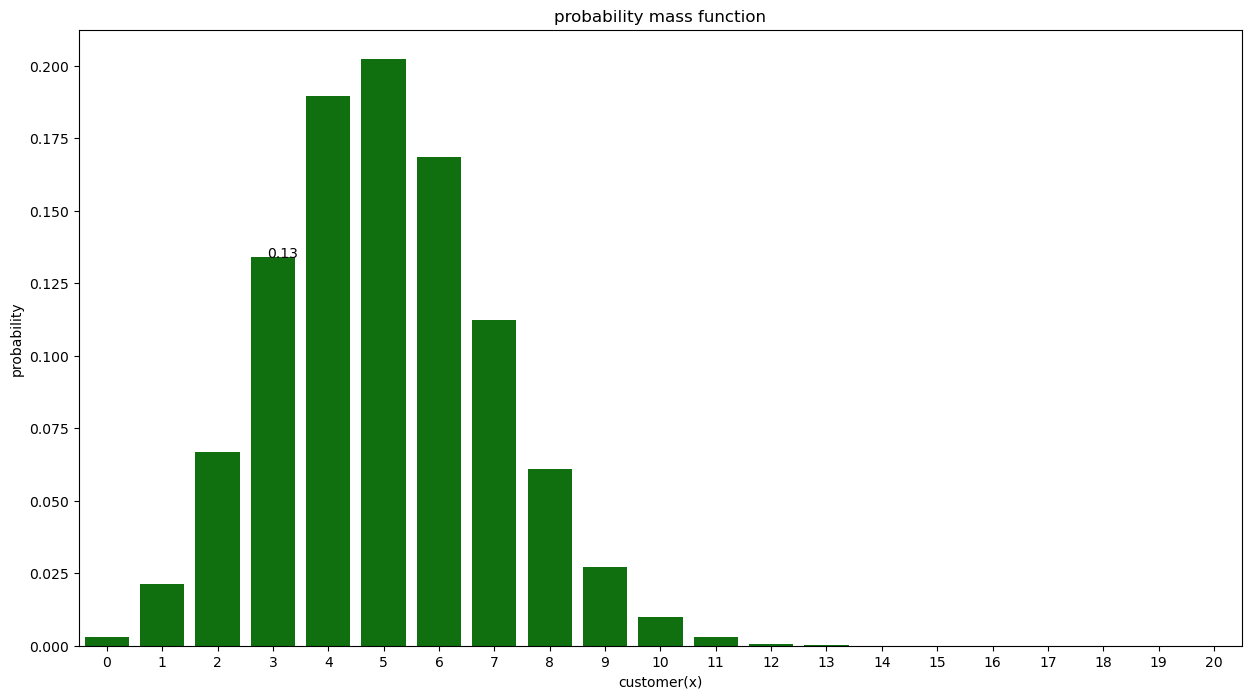

In [14]:
import seaborn as sns
#we plot a barplot to visualizepmf
# the sample space of X 
X=np.arange(0,21)
p=0.25
binom_pmf=stats.binom.pmf(k=X,n=20,p=0.25)
plt.figure(figsize=(15,8))
sns.barplot(x=X,y=binom_pmf,color='green')
plt.text(x=2.9,y=binom_pmf[3],s=np.round(binom_pmf[3],2))
plt.xlabel('customer(x)')
plt.ylabel('probability')
plt.title("probability mass function")
plt.show()

In [ ]:
#b. Calculate the probability that more than 3 customers will complain about the furniture purchased by them


In [12]:
prob_more3=stats.binom.sf(k=3,n=20,p=0.25)
print("the probability that more than 3 customers will complain about the furniture purchased by them",np.round(prob_more3,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the probability that more than 3 customers will complain about the furniture purchased by them 0.77


In [ ]:
#2. In a shooting academy, data was collected on the precision shooting of a student. From 15 shots fired 11 were on target. 
#Consider the same student, what is the probability that out of 50 shots fired, exactly 35 will hit the target?

In [ ]:
lets consider student X as a discrete random variable which follows binomial distribution with n=50 , p=11/15

In [15]:
prob_hit_target=stats.binom.pmf(k= 35,n=50,p=11/15)
print("the probability that out of 50 shots fired, exactly 35 will hit the target",np.round(prob_hit_target,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the probability that out of 50 shots fired, exactly 35 will hit the target 0.11


In [ ]:
lets visualize the samplespace X 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

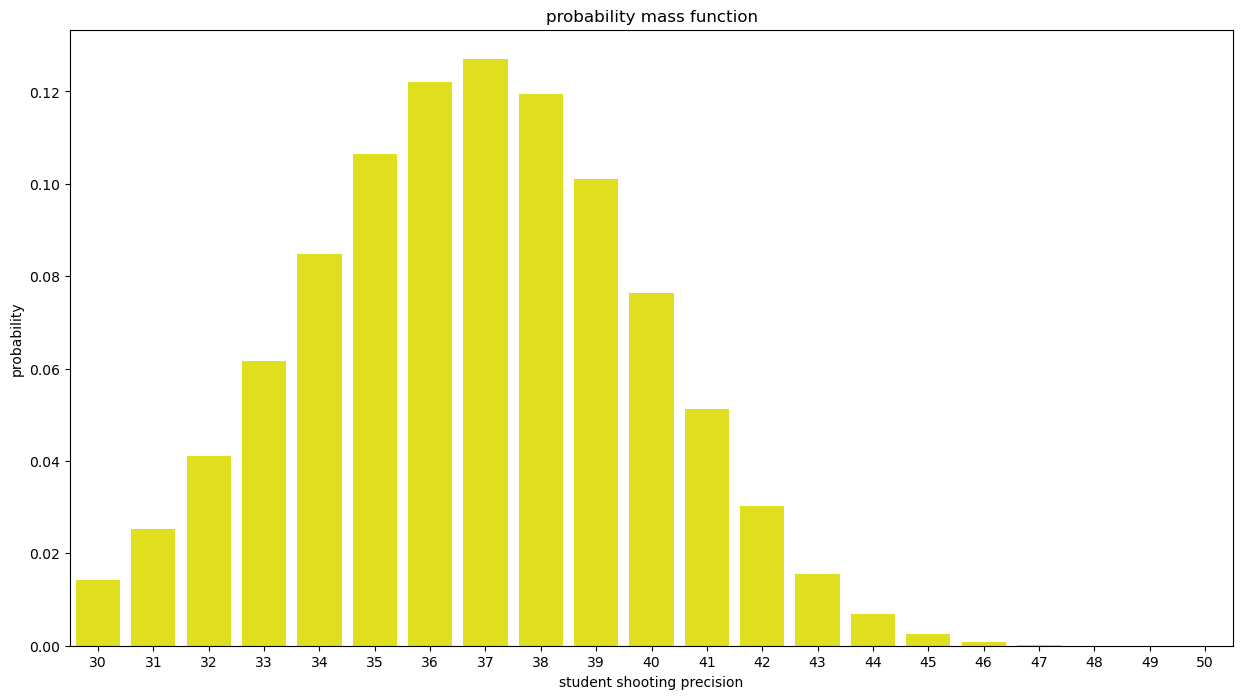

In [22]:
X1=np.arange(30,51)
binom_pmf1=stats.binom.pmf(k=X1,n=50,p=11/15)
plt.figure(figsize=(15,8))
sns.barplot(x=X1,y=binom_pmf1,color='yellow')
plt.xlabel("student shooting precision")
plt.ylabel("probability")
plt.title("probability mass function")
plt.show()

### poission distribution

In [ ]:
### Example:

#1. The number of pizzas sold per day by a food zone "Fapinos" follows a poisson distribution at a rate of 67 pizzas per day.
#Calculate the probability that the number of pizza sales exceeds 70 in a day.**

In [ ]:
The mean and variance of the distribution is given as:

Mean = 
 = Variance

Note: Consider a variable X that follows a binomial distribution with parameters n and p. If n -> infinity
 and p =0 then X follows a poison distribution with parameter m = np.

In [ ]:
 consider the discrete random variable X as the number of pizzas sold per day.here X follows poission distribution  m=67

In [28]:
prop=stats.poisson.sf(k=70 , mu = 67)
print("the probability that the number of pizza sales exceeds 70 in a day.",np.round(prop,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the probability that the number of pizza sales exceeds 70 in a day. 0.33


In [ ]:
We plot a distribution plot to visualize the cdf of X.


<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_25360\3997087602.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=poisson_X , hist_kws=dict(cumulative=True),kde_kws=dict(cumulative=True))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

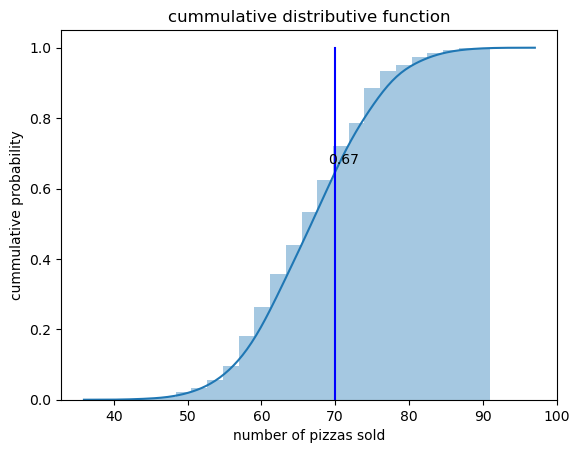

In [39]:
poisson_X = stats.poisson.rvs(mu = 67,size=1000,random_state=10)
# plot the cdf of X
# pass the data to the parameter, 'a'
# 'cumulative=True' in 'kde_kws' returns the cumulative kernel density estimator
# 'cumulative=True' in 'hist_kws' returns the cumulative histogram
sns.distplot(a=poisson_X , hist_kws=dict(cumulative=True),kde_kws=dict(cumulative=True))
# plot a vertical line at X = 70
x,y =[70,70] ,[0,1]
plt.plot(x,y,color='blue')
# use below code to print the value of P(X ≤ 70) in the graph
# 'x' and 'y' gives position of the text
# 's' is the text 


plt.text(x=69,y=stats.poisson.cdf(k = 70,mu=67),s=np.round(stats.poisson.cdf(k = 70,mu=67),2))

plt.xlabel("number of pizzas sold")
plt.ylabel("cummulative probability")
plt.title("cummulative distributive function")
plt.show()

In [ ]:
#2. The number of calls received at a telephone exchange in a day follows poisson distribution. 
#The probability that the exchange receives 5 calls is three times that of the exchange receiving 10 calls.
#Obtain the average calls that the telephone exchange receives in a day.¶

In [51]:
from math import factorial
# given: P(X = 5) = 3*P(X = 10)
# to find: m = average number of calls
# solving the above equation we get
m_raised_5 = factorial(10) / (3* factorial(5))

# value of 'm'
m = m_raised_5**(1/5)

# as the number of calls is an integer, convert the value of 'm' using int() 
print('Average calls that the telephone exchange receives in a day', int(m))

Average calls that the telephone exchange receives in a day 6


# Normal Distribution

In [ ]:
#1. A survey was conducted and it was found that the people spend their 300 minutes in a day surfing on online shopping sites on average and
#the corresponding standard deviation is 127 minutes.
#Assume that the time spent on surfing follows a normal distribution. Calculate the following probabilities:

In [ ]:
z= (x-mean )  / sigma

In [4]:
# on avg people spend their 300 minutes in a day
mean=300
#standard deviation is 127 minutes.
std=127
#standardize the variable with x=100
z= (100 - mean) / std

#### a. What is the probability that the users are spending less than or equal to 100 minutes per day?

In [7]:
#cdf returns the p( Z <= 100)
prob = stats.norm.cdf(z)
print("the probability that the users are spending less than or equal to 100 minutes per day",np.round(prob,2))

<IPython.core.display.Javascript object>

the probability that the users are spending less than or equal to 100 minutes per day 0.06


In [ ]:
visual

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_25852\2626606423.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=x,hist_kws= dict(cumulative=True), kde_kws=dict(cumulative=True))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

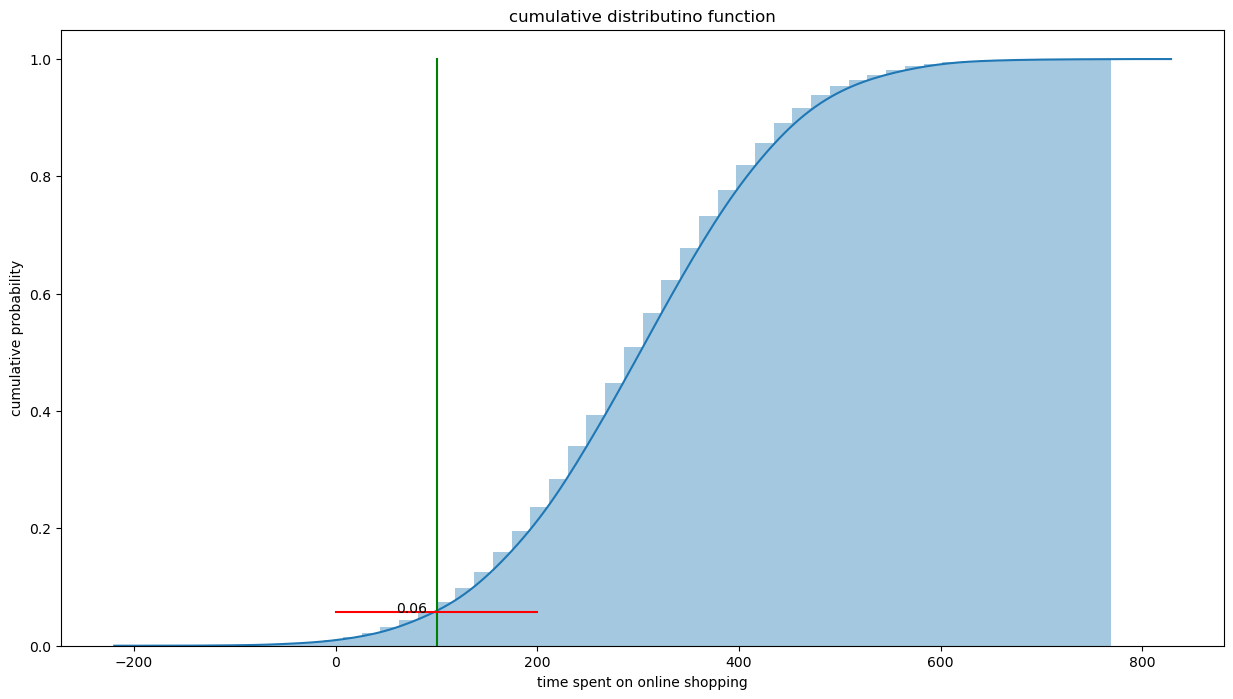

In [25]:
x=stats.norm.rvs(loc=300,scale=127,size=10000,random_state=10)

plt.figure(figsize=[15,8])
sns.distplot(a=x,hist_kws= dict(cumulative=True), kde_kws=dict(cumulative=True))
#plot horizontal line
x,y = [100,100],[0,1]
plt.plot(x,y,color='green')
#plot vertical line
x,y= [0,200],[stats.norm.cdf(z),stats.norm.cdf(z)]
plt.plot(x,y,color='red')

plt.text(x=60,y=stats.norm.cdf(z),s=np.round(stats.norm.cdf(z),2))

plt.xlabel("time spent on online shopping")   
plt.ylabel("cumulative probability")
plt.title("cumulative distributino function")
plt.show()             

#### b. What is the probability that people are spending more than 400 minutes on online shopping sites per day?


In [38]:
avg= 300
std=127
X=400

z= (400 - avg) / std


In [39]:
#calculate teh probability the people are surfing more then400 minutes
#sf() returns P(Z > z)  P(Z > 400)
prob=stats.norm.sf(z)
req_prob=np.round(prob,2)
print("the probability that people are spending more than 400 minutes on online shopping sites per day",req_prob)

<IPython.core.display.Javascript object>

the probability that people are spending more than 400 minutes on online shopping sites per day 0.22


#### c. What is the probability that people are spending time between 250 minutes and 350 minutes per day?

In [48]:
avg= 300
std=127
#between 250 minutes and 350 minutes
#standardize teh variable with x= 250
#z=( x - mean ) / std
z_250=  (250 - avg ) / std
#cdf() returns P(Z <= 250)
P_250 = stats.norm.cdf(z_250)
#standardize the variable with x=350
z_350= (350 - avg) / std
#sf() returns P(Z >= 350)
P_350 = stats.norm.cdf(z_350)
prob= z_350 - z_250
print("the probability that people are spending time between 250 minutes and 350 minutes per day",np.round(prob,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the probability that people are spending time between 250 minutes and 350 minutes per day 0.79


#### 2. A monthly balance in the bank account of a credit card holders is assumed to be normally distributed with mean 500 dollars and variance 100 dollars. What is the probability that the balance can be more than 513.5 dollars?

In [51]:
#z= (x - mean) / std 
mean=500
var=100
std=np.sqrt(var)
#standardize the variable with x=513
z= (513.5 - mean) / std
#sf() returns P(Z> 513.5)
prob = stats.norm.sf(z)
print("the probability that the balance can be more than 513.5 dollars",np.round(prob,4))

<IPython.core.display.Javascript object>

the probability that the balance can be more than 513.5 dollars 0.0885


#### random sampling 

In [ ]:
#with replacement
1. Consider 8 identical boxes that contain different number of shuttlecocks. Draw a sample of 20 boxes with replacement.

In [53]:

data = [18, 13, 16, 17, 15, 21, 19, 12]
random_sampling_with_replacement = random.choices(population=data,k=20)
print("sample of 20 boxes with replacement.",random_sampling_with_replacement)

<IPython.core.display.Javascript object>

sample of 20 boxes with replacement. [15, 21, 18, 17, 19, 18, 19, 16, 21, 18, 19, 21, 12, 17, 16, 16, 18, 18, 19, 12]


In [ ]:
#without replacement
1. An ice-cream manufacturer wants to study the sales of ice-creams to decide the production policies of the company. He collects the data for the number of ice-creams sold in a month from the 30 franchise. Randomly select the sales of 10 franchise for the study.
data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]

In [54]:
data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]
random_sample_without_replacement = random.sample(population=data,k=10)
print("sample of 10 boxes without replacement",random_sample_without_replacement )

<IPython.core.display.Javascript object>

sample of 10 boxes without replacement [92, 10, 36, 11, 29, 38, 14, 80, 13, 56]


# central limit theorm

Let $X_{1}, X_{2}, X_{3},..., X_{n}$ be the random sample drawn from a population with mean $\mu$ and standard deviation $\sigma$. The central limit theorem states that, for sufficiently large n, the sample mean $\overline{X}$ follows an approximately normal distribution with mean $\mu$ and standard deviation $\frac{\sigma}{\sqrt{n}}$.

i.e. $\frac{\overline{X} - \mu}{\frac{\sigma}{\sqrt{n}}}$ follows a standard normal distribution.

For a normally distributed population, the above result holds for any sample size.

For the population with distribution other than normal, generally, the sample size greater than or equal to 30 is considered as the large sample size.

In [32]:
# define a function to obtain the sample means for given population
# pass the population and and number of samples as the input parameters
def sample_mean_calculator(population,no_of_samples):
    sample_means=[]
    for i in range(no_of_samples):
        sample=np.random.choice(population,size=500,replace=False)
        sample_mean=np.mean(sample)
        sample_means.append(sample_mean)
    return sample_means
   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

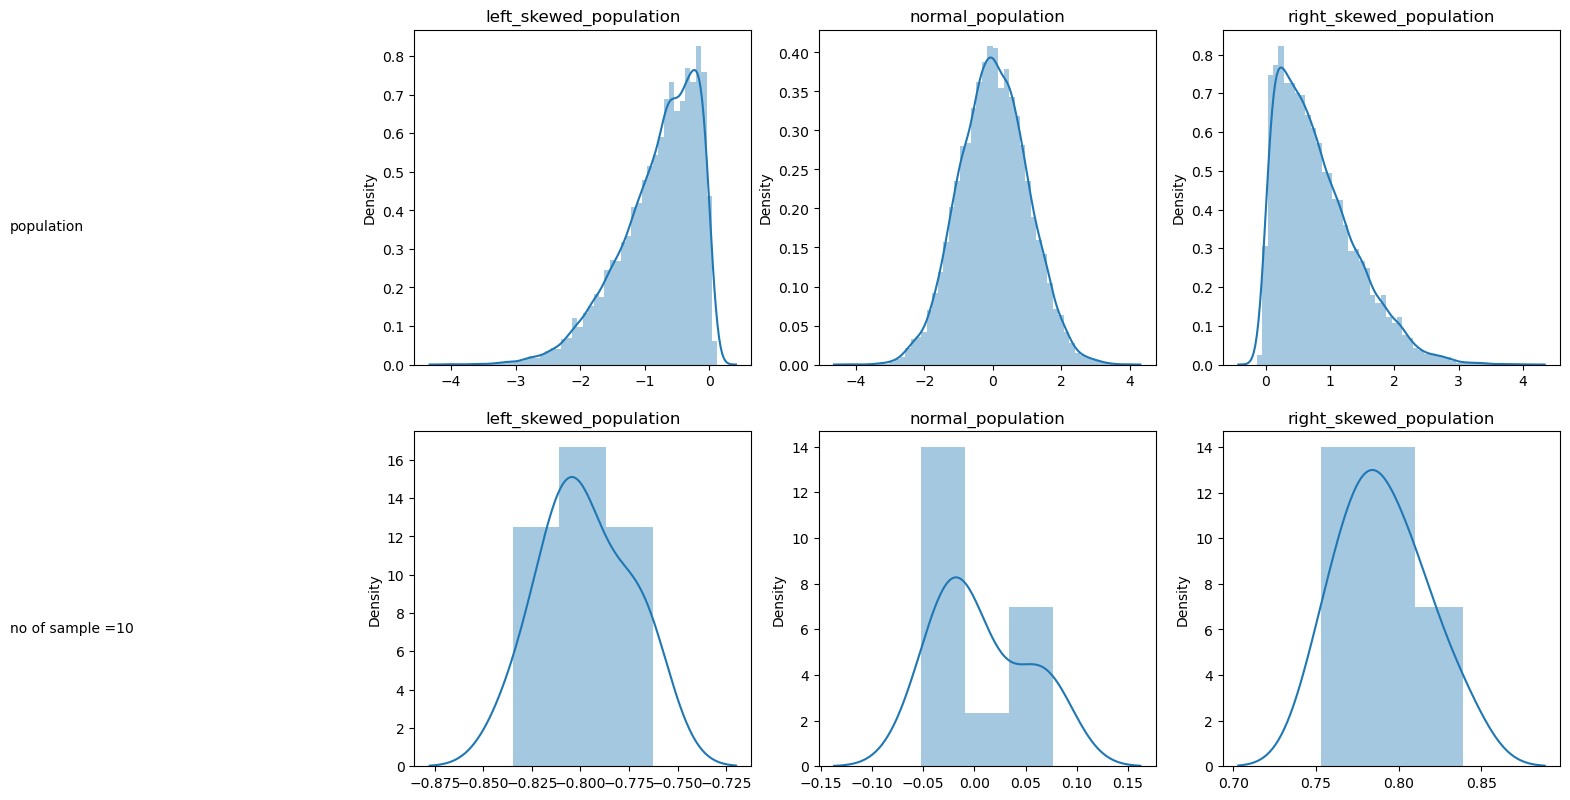

In [66]:
import matplotlib.gridspec as gridspec
from scipy.stats import skewnorm

def sample_mean_cal(population,no_of_samples):
   sample_means=[]
   for i in range(no_of_samples):
       sample=np.random.choice(population,size=500,replace=False)
       sample_mean=np.mean(sample)
       sample_means.append( sample_mean)
   return sample_means 

plt.rcParams["figure.figsize"] = [20,20]
gs=gridspec.GridSpec(nrows=4,ncols=4, width_ratios=[3,3,3,3],height_ratios=[2,2,2,2])
gs


left_skewed_population=stats.skewnorm.rvs(-20,size=10000,random_state=1)
normal_population = stats.skewnorm.rvs(0,size=10000,random_state=1)
right_skewed_population = stats.skewnorm.rvs(20,size=10000,random_state=1) 
 #--------------------------------
t1=plt.subplot(gs[0,0])
t1.text(0.0 , 0.4, s=str("population"))
t1.axis('off')

a1=plt.subplot(gs[0,1])
a1.set_title("left_skewed_population")
a1=sns.distplot(left_skewed_population)

b1=plt.subplot(gs[0,2])
b1.set_title("normal_population")
b1=sns.distplot(normal_population)

c1=plt.subplot(gs[0,3])
c1.set_title("right_skewed_population")
c1=sns.distplot(right_skewed_population)
#--------------------------------
#
t1=plt.subplot(gs[1,0])
t1.text(0.0 , 0.4, s=str("no of sample =10"))
t1.axis('off')

d1=plt.subplot(gs[1,1])
d1.set_title("left_skewed_population")
d1=sns.distplot(sample_mean_cal(left_skewed_population,10))

e1=plt.subplot(gs[1,2])
e1.set_title("normal_population")
e1=sns.distplot(sample_mean_cal(normal_population,10))

f1=plt.subplot(gs[1,3])
f1.set_title("right_skewed_population")
f1=sns.distplot(sample_mean_cal(right_skewed_population,10))


In [51]:
from scipy.stats import skewnorm
import matplotlib.gridspec as gridspec

from warnings import filterwarnings
filterwarnings('ignore')


# set the plot size
plt.rcParams["figure.figsize"] = [25,25]

# divide the plot into the specified number of subplots 
gs = gridspec.GridSpec(10, 5, width_ratios=[2, 3, 3, 3, 3], height_ratios=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
gs


<IPython.core.display.Javascript object>

GridSpec(10, 5, width_ratios=[2, 3, 3, 3, 3])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

IndexError: index 4 is out of bounds for axis 0 with size 4

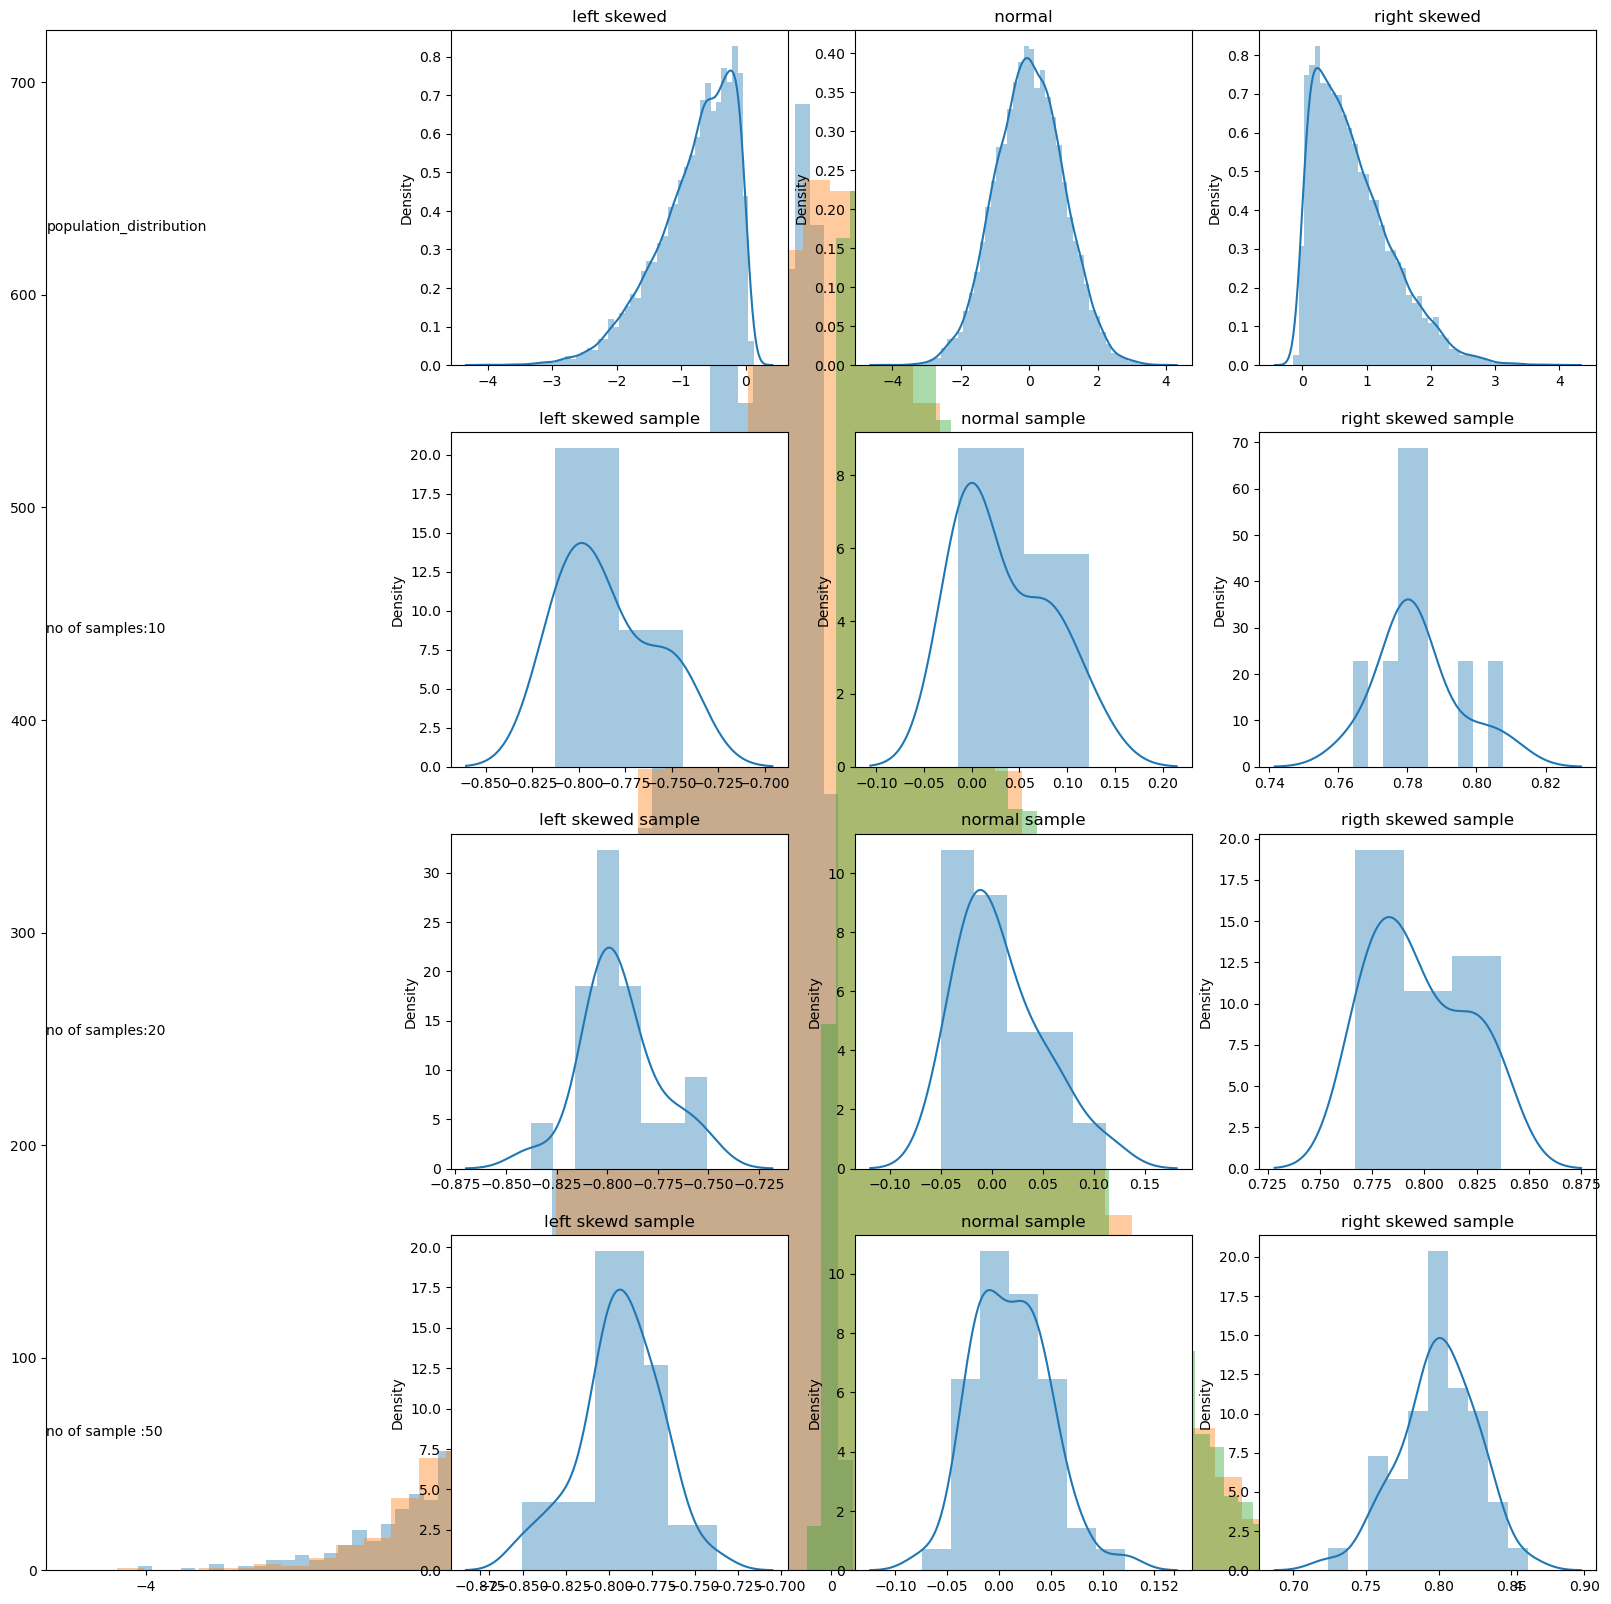

In [67]:
# generate a left skewed data
l_skew_population= stats.skewnorm.rvs(-20,size=10000,random_state = 1)
sns.distplot(l_skew_population,kde=False)

# generate a normally distributed data
normal_distribution_population = stats.skewnorm.rvs(0,size=10000,random_state = 1)
sns.distplot(normal_distribution_population,kde= False)

# generate a right skewed data
r_skew_population = stats.skewnorm.rvs(20,size=10000,random_state = 1)
sns.distplot(r_skew_population,kde=False)

#for the text
t1=plt.subplot(gs[0, 0])
t1.text(0.0 , 0.4 ,s=str("population_distribution"))
t1.axis('off')

# for left skewed population
a1=plt.subplot(gs[0, 1])
a1.set_title("left skewed")
a1=sns.distplot(l_skew_population)

#for normal distribution population
b1=plt.subplot(gs[0,2])
b1.set_title(" normal ")
b1=sns.distplot(normal_distribution_population)


#for right skew population
c1=plt.subplot(gs[0,3])
c1.set_title("right skewed")
c1=sns.distplot(r_skew_population )

#-------------------------------------------

#no of samples =10
#for the text
t2=plt.subplot(gs[1,0])
t2.text(0.0,0.4,s=str("no of samples:10"))
t2.axis('off')  

#for left skewed population sample
d1=plt.subplot(gs[1,1])
d1.set_title("left skewed sample")
d1=sns.distplot(sample_mean_calculator(l_skew_population,10))

#for normal population sample
e1=plt.subplot(gs[1,2])
e1.set_title("normal sample")
e1=sns.distplot(sample_mean_calculator(normal_distribution_population,10 ))

#for right skewed population
f1=plt.subplot(gs[1,3])
f1.set_title("right skewed sample")
f1=sns.distplot(sample_mean_calculator(r_skew_population,10))

#------------------------------------------------
#no of samples 20
t3=plt.subplot(gs[2,0])
t3.text(0.0, 0.4, s=str("no of samples:20"))
t3.axis("off")

#for left skew samples"
g1=plt.subplot(gs[2,1])
g1.set_title("left skewed sample")
g1=sns.distplot(sample_mean_calculator(l_skew_population,20))

#for normal sample
f1=plt.subplot(gs[2,2])
f1.set_title("normal sample")
f1=sns.distplot(sample_mean_calculator(normal_distribution_population,20))

#for right skew sample
h1=plt.subplot(gs[2,3])
h1.set_title("rigth skewed sample")
h1=sns.distplot(sample_mean_calculator(r_skew_population,20))

#_--------------------------------------------

#no  of sample= 50

t4=plt.subplot(gs[3,0])
t4.text(0.0,0.4,s=str("no of sample :50"))
t4.axis('off')

#left skew sample
i1=plt.subplot(gs[3,1])
i1.set_title("left skewd sample")
i1=sns.distplot(sample_mean_calculator(l_skew_population,50))

#normal sample
j1= plt.subplot(gs[3,2])
j1.set_title("normal sample")
j1=sns.distplot(sample_mean_calculator(normal_distribution_population,50))
                      
#right skew sample
k1=plt.subplot(gs[3,3])
k1.set_title("right skewed sample")
k1=sns.distplot(sample_mean_calculator(r_skew_population,50))



#no of samples = 100
t4=plt.subplot(gs[4,0])
t4.text(0.0,0.4,s=str("no of sample 100"))
t4.axis('off')

#left skew sample
m1=plt.subplot(gs[4,1])
m1.text(0.0,0.4,s=str("left skewd sample"))
m1=sns.distplot(sample_mean_calculator(l_skew_population,100))

#normal sample
n1= plt.subplot(gs[4,2])
n1.text(0.0 , 0.4,s=str("normal skewd sample"))
n1=sns.distplot(sample_mean_calculator(normal_distribution_population,100))
#right sample
o1=plt.subplot(gs[4,3])
o1.text(0.0 , 0.4,s=str("right skewd sample"))
o1=sns.distplot(sample_mean_calculator(r_skew_population,100))


#no of sample=5000
t5=plt.subplot(gs[5,0])
t5.text(0.0,0.4,"no of samples:5000")
t5.axis('off')

#left skew sample
p1=plt.subplot(gs[5,1])
p1.text(0.0,0.4,s=str("left skewd sample"))
p1=sns.distplot(sample_mean_calculator(l_skew_population,5000))

#normal sample
q1= plt.subplot(gs[5,2])
q1.text(0.0 ,0.4,s=str("normal"))
q1= sns.distplot(sample_mean_calculator(normal_distribution_population,5000))

#right skew sample
r1=plt.subplot(gs[5,3])
r1.text(0.0 , 0.4 , s= str("right skewd sample"))
r1=sns.distplot(sample_mean_calculator(r_skew_population,5000))


### point estimation

# 1. Consider the data of grade points for 35 students in a data science course. Select grades of 20 students randomly from the data and find the point estimate for the population mean.
 Grades: [59.1, 65.0, 75.8, 79.2, 95.0, 99.8, 89.1, 65.2, 41.9, 55.2, 94.8, 84.1, 83.2, 74.0, 75.5, 76.2, 79.1, 80.1, 
          92.1, 74.2, 59.2, 64.0, 75, 78.2, 95.6, 97.8, 89.5, 64.2, 41.8, 57.2, 85, 91.4, 81.8, 74.6, 90]

In [68]:
Grades= [59.1, 65.0, 75.8, 79.2, 95.0, 99.8, 89.1, 65.2, 41.9, 55.2, 94.8, 84.1, 83.2, 74.0, 75.5, 76.2, 79.1, 80.1, 
          92.1, 74.2, 59.2, 64.0, 75, 78.2, 95.6, 97.8, 89.5, 64.2, 41.8, 57.2, 85, 91.4, 81.8, 74.6, 90]
random.seed(1)
samplee= random.sample(Grades, k = 20)
sample_mean=np.mean(samplee)
print("grades of 20 students randomly from the data",samplee)
print("the point estimate for the population mean",sample_mean)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

grades of 20 students randomly from the data [41.9, 95.0, 79.1, 65.2, 76.2, 95.6, 75.5, 85, 59.2, 83.2, 89.1, 79.2, 64.2, 59.1, 97.8, 74.0, 64.0, 41.8, 90, 91.4]
the point estimate for the population mean 75.32500000000002


# 2.A financial firm has created 50 portfolios. From them, a sample of 13 portfolios was selected,
out of which 8 were found to be underperforming. Can you estimate the number of underperforming portfolios?¶

In [70]:
total_portfolios= 50
sample=13
underperforming=8
sample_ratio=underperforming / sample
no_of_underperforming=total_portfolios * sample_ratio
print("the number of underperforming portfolios",np.round(no_of_underperforming))

<IPython.core.display.Javascript object>

the number of underperforming portfolios 31.0


### Sampling Error
Sampling error is considered as the absolute difference between the sample statistic used to estimate the parameter and the corresponding population parameter. Since the entire population is not considered as the sample, the values of mean, median, quantiles, and so on calculated on sample differ from the actual population values.

One can reduce the sampling error either by increasing the sample size or determining the optimal sample size using various methods.

##  1. Consider the data for the number of ice-creams sold per day. An ice-cream vendor collected this data for 90 days and then a sample is drawn (without replacement) containing ice-creams sold for 25 days.
data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91, 94, 49, 57, 83, 96, 55, 79, 52, 59, 39, 58, 17, 19, 98, 15, 54, 48, 46, 72, 45, 65, 28, 37, 30, 68, 75, 16, 33, 31, 99, 22, 51, 27, 67, 85, 47, 44, 77, 64, 97, 84, 42, 90, 70, 74, 89, 32, 26, 24, 12, 81, 53, 50, 35, 71, 63, 43, 86, 78, 66]

sample = [10, 22, 47, 66, 11, 57, 77, 98, 31, 63, 74, 84, 50, 96, 88, 92, 70, 54, 65, 44, 16, 72, 20, 90, 43]

Comupte the sampling error for mean.



In [74]:
data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91, 94, 49, 57, 83, 96, 55, 79, 52, 59, 39, 58, 17, 19, 98, 15, 54, 48, 46, 72, 45, 65, 28, 37, 30, 68, 75, 16, 33, 31, 99, 22, 51, 27, 67, 85, 47, 44, 77, 64, 97, 84, 42, 90, 70, 74, 89, 32, 26, 24, 12, 81, 53, 50, 35, 71, 63, 43, 86, 78, 66]

sample = [10, 22, 47, 66, 11, 57, 77, 98, 31, 63, 74, 84, 50, 96, 88, 92, 70, 54, 65, 44, 16, 72, 20, 90, 43]

sample_mean=np.mean(sample )
population_mean = np.mean(data)

print("sampling error for mean",np.abs(sample_mean - population_mean))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sampling error for mean 3.1000000000000014


## Interval Estimation for Mean¶

# 1. A random sample of weight (in kg.) for 35 diabetic patients is drawn from the population with a standard deviation of 8 kg.
Find the 90% confidence interval for the population mean.
Weight: [59.1, 65.0, 75.8, 79.2, 95.0, 99.8, 89.1, 65.3, 41.9, 55.2, 94.8, 84.1, 83.2, 74.0, 75.5, 76.2, 79.1, 80.1, 
         92.1, 74.2, 59.2, 64.0, 75, 78.2, 95.6, 97.8, 89.5, 64.2, 41.8, 57.2, 85, 91.4, 81.8, 74.6, 90]

In [78]:
weight= [59.1, 65.0, 75.8, 79.2, 95.0, 99.8, 89.1, 65.3, 41.9, 55.2, 94.8, 84.1, 83.2, 74.0, 75.5, 76.2, 79.1, 80.1, 
         92.1, 74.2, 59.2, 64.0, 75, 78.2, 95.6, 97.8, 89.5, 64.2, 41.8, 57.2, 85, 91.4, 81.8, 74.6, 90]
std_dev= 8
n=len(weight)
confidence_interval=stats.norm.interval(0.90,loc=np.mean(weight) ,scale = std_dev / np.sqrt(n))
print("the 90% confidence interval for the population mean.",np.round(confidence_interval,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the 90% confidence interval for the population mean. [74.46 78.91]


# 2. There are 150 apples on a tree. You randomly choose 40 apples and found that the average weight of apples is 182 grams with a standard deviation of 30 grams. Find the 95% confidence interval for the population mean.


In [80]:
sample_size=40
sample_mean=182
sample_stddev=30
confidence_interval=stats.norm.interval(0.95,loc=sample_mean,scale= sample_stddev / np.sqrt(sample_size))
print("the 95% confidence interval for the population mean.",np.round(confidence_interval,2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

the 95% confidence interval for the population mean. [172.7 191.3]


# 3. A movie production house needs to estimate the average monthly wage of the technical crew members. The previous data shows that the standard deviation of the wages is 190 dollars. The production team thinks that the estimation of the average wage should not exceed 54 dollars. The team has decided to take a small subset of wages for the estimation. Find a suitable number of wages to be considered to get the estimate with 90% confidence.


In [2]:
sigma=190
margin_error=54
# calculate z_alpha_by_2 with alpha = 0.1
# use 'stats.norm.isf()' to find the Z-value corresponding to the upper tail probability 'q'
# pass the value of 'alpha/2' to the parameter 'q'
# use 'round()' to round-off the value to 4 digits
z_alpha_by_2=np.abs(round(stats.norm.isf(q=0.1 / 2),4))
sample_size = ((z_alpha_by_2 ** 2)  * (sigma **2) )/ (margin_error**2)
print("sample_size",sample_size )

<IPython.core.display.Javascript object>

sample_size 33.49644237345679


# 4. 100 bags of coal were tested and had an average of 35% of ash with a standard deviation of 15%. Calculate the margin of error for a 90% confidence level.


In [4]:
no_of_bags=100
sted_dev=0.15
confidence_level=0.90
z_alpha_by_2 = np.abs(round(stats.norm.isf(q=0.1 / 2),4))
marginal_error=  (z_alpha_by_2 * sted_dev ) / np.sqrt(no_of_bags)
print("marginal error",marginal_error)

<IPython.core.display.Javascript object>

marginal error 0.024673499999999998


# 5. From a sample of 250 observations, it is found that the average income of a 27 year old Londoner is £45,000 with a sample standard deviation of £4000. Obtain the 95% confidence interval to estimate the average income.¶

In [5]:
sample_size = 250
sample_mean=45000
sample_std_dev=4000
confidence_interval = stats.norm.interval(confidence= 0.95,loc= sample_mean , scale = sample_std_dev / np.sqrt(sample_size))
print("the 95% confidence interval to estimate the average income",confidence_interval)

<IPython.core.display.Javascript object>

the 95% confidence interval to estimate the average income (44504.16397415635, 45495.83602584365)


#  Small Sample Size

# 1 There are 150 apples on a tree. You randomly choose 17 apples and found that the average weight of apples is 78 grams with a standard deviation of 23 grams. Find the 90% confidence interval for the population mean.¶

In [7]:
observed_sample_size=17  # sampel size less than 30
sample_mean = 78
sample_stddev = 23
confidenceinterval = stats.t.interval(confidence = 0.90 ,loc=sample_mean , df = (observed_sample_size - 1),scale= sample_stddev / np.sqrt(observed_sample_size))
print("the 90% confidence interval for the population mean",confidenceinterval)

<IPython.core.display.Javascript object>

the 90% confidence interval for the population mean (68.26090326067306, 87.73909673932694)


#  Interval Estimation for Proportion

# 1 A financial firm has created 50 portfolios. From them, a sample of 13 portfolios was selected, out of which 8 were found to be underperforming. Construct a 99% confidence interval to estimate the population proportion.

In [10]:
total_count_portfolios = 50
sample_size= 13
under_performing_portfolios = 8
sample_proportion=under_performing_portfolios /sample_size
interval = stats.norm.interval(confidence=0.99,loc=sample_proportion,scale=  np.sqrt((sample_proportion*(1-sample_proportion))/total_count_portfolios))
print("interval",interval)

<IPython.core.display.Javascript object>

interval (0.43816217165626825, 0.7926070591129626)


# Hypothesis Tests with Z Statistic

1. A car manufacturing company claims that the mileage of their new car is 25 kmph with a standard deviation of 2.5 kmph. A random sample of 45 cars was drawn and recorded their mileage as per the standard procedure. From the sample, the mean mileage was seen to be 24 kmph. Is this evidence to claim that the mean mileage is different from 25kmph? (assume the normality of the data) Use α = 0.01

In [14]:
#H0 : mu = 25
#H1 : mu != 25
 #get zscore
zval=np.abs(round(stats.norm.isf(q=0.01 / 2),2))
print("critical value",zval)

<IPython.core.display.Javascript object>

critical value 2.58


In [21]:
# define a function to calculate the Z-test statistic 
# pass the population mean, population standard deviation, sample size and sample mean as the function input
def z_test(pop_mean, pop_std, n, samp_mean):
   
    # calculate the test statistic
    z_score = (samp_mean - pop_mean) / (pop_std / np.sqrt(n))

    # return the z-test value
    return z_score

# given data
n = 45
pop_mean = 25
pop_std = 2.5
samp_mean = 24

# calculate the test statistic using the function 'z_test'
z_score = z_test(pop_mean, pop_std, n, samp_mean)
print("Z-score:", z_score)

Z-score: -2.6832815729997477


In [23]:
pvalue= stats.norm.cdf(z_score)
pvalue= pvalue* 2  # since two tail test
print("pvalue",pvalue)

<IPython.core.display.Javascript object>

pvalue 0.007290358091535638


In [24]:
# calculate the 99% confidence interval for the population mean
# pass the sample mean to the parameter, 'loc'
# pass the scaling factor (pop_std / n^(1/2)) to the parameter, 'scale'
confidenceinterval =stats.norm.interval(confidence=0.99,loc= samp_mean , scale = pop_stddev / np.sqrt(n))
print("confidenceinterval",confidenceinterval)

<IPython.core.display.Javascript object>

confidenceinterval (23.040045096471452, 24.959954903528548)


Here the z score is less than -2.58, p-value is less than 0.01, also the confidence interval do not contain the value in the null hypothesis (i.e. 25), thus we reject the null hypothesis and conclude that there is enough evidence to claim that the mean mileage is different from 25kmph.

 1. # A car manufacturing company claims that the mileage of their new car is 25 kmph with a standard deviation of 2.5 kmph. A random sample of 45 cars was drawn and recorded their mileage as per the standard procedure. From the sample, the mean mileage was seen to be 24 kmph. Is this evidence to claim that the mean mileage is different from 25kmph? (assume the normality of the data) Use α = 0.01

In [ ]:
H0 : mu = 25
H1 : mu!=25

z-score, also known as a standard score, is an important statistical measure that helps you understand where data lies in a distribution. It's useful for many reasons, including


In [33]:

#get zscore
pop_mean=25
pop_std=2.5
sample_size=45
samp_mean = 24
zscore = (samp_mean - pop_mean) / (pop_std / np.sqrt(sample_size))
print("zscore",zscore)

zscore -2.6832815729997477


In [27]:
#get confidence interval
ci=stats.norm.interval(confidence=0.99,loc=samp_mean,scale= ( pop_std / np.sqrt(sample_size)))
print("confidence interval",ci)                       

<IPython.core.display.Javascript object>

confidence interval (23.040045096471452, 24.959954903528548)


In [34]:
#get zvalue
zval=stats.norm.isf(q=0.01 / 2)
print("zvalue",zval)

<IPython.core.display.Javascript object>

zvalue 2.575829303548901


In [36]:
#get pvalue
alpha = 0.01
pval=stats.norm.cdf(zscore)
pval=pval * 2
print("pvalue",pval)
if pval < alpha:
    print("reject null")
else:
    print("failed to reject null")

<IPython.core.display.Javascript object>

pvalue 0.007290358091535638
reject null


Here the z score is less than -2.58, p-value is less than 0.01, also the confidence interval do not contain the value in the null hypothesis (i.e. 25), thus we reject the null hypothesis and conclude that there is enough evidence to claim that the mean mileage is different from 25kmph.

# 2. The average calories in a slice bread of the brand 'Alphas' are 82 with a standard deviation of 15. An experiment is conducted to test the claim of the dietitians that the calories in a slice of bread are not as per the manufacturer's specification. A sample of 40 slices of bread is taken and the mean calories recorded are 95. Test the claim of dietitians with ⍺ value (significance level) as 0.05. (assume the normality of the data).

In [ ]:
H0: mu =82
H1 : mu != 82

In [40]:
#given data
pop_mean=82
pop_stddev=15
sample_size=40
sample_mean=95
alpha=0.05

zscore = ((sample_mean - pop_mean) / ( pop_stddev / np.sqrt(sample_size )))
print("zscore",np.round(zscore,2))

zscore 5.48


In [217]:
import scipy.stats as st
#get critical region
ci=stats.norm.interval(confidence=0.95, loc=sample_mean ,scale= (pop_stddev / np.sqrt(sample_size)))
print("critical region",np.round(ci,2))


AttributeError: 'numpy.float64' object has no attribute 'norm'

In [71]:
#get zval
zval=stats.norm.isf(q=0.05 / 2)
print("zval",np.round(zval,2))

AttributeError: 'numpy.float64' object has no attribute 'norm'

In [48]:
#get pvalue
pvalue=stats.norm.cdf(-zscore)
pvalue=pvalue * 2
print("pvalue",pvalue)
if pvalue < alpha :
    print("reject null")
else:
    print("failed to reject null")

<IPython.core.display.Javascript object>

pvalue 4.222565249683579e-08
reject null


Here the z score is greater than 1.96, the p-value is less than 0.05, also the confidence interval do not contain the value in the null hypothesis (i.e. 82), thus we reject the null hypothesis and thus, there is enough evidence to conclude that the average calories in a slice bread are not 82.

# 3. A typhoid vaccine in the market inscribes 3 mg of ascorbic acid in the vaccine. A research team claims that the vaccines contain less than 3 mg of acid. We collected the data of 40 vaccines by using random sampling from a population and recorded the amount of ascorbic acid. Test the claim of the research team using the sample data ⍺ value (significance level) to 0.05.

The Shapiro-Wilk test is a statistical hypothesis test that determines if a sample of data comes from a normally distributed population: 
 
Null hypothesis: The sample comes from a normally distributed population 
 
Alternative hypothesis: The sample does not come from a normally distributed population 
 
Test statistic: The W statistic measures how well the sample distribution matches the normal distribution 
 
P-value: The probability of observing the given data if the null hypothesis is true 
 


In [88]:
from scipy.stats import shapiro
#perform shapiro test
# perform Shapiro-Wilk test to test the normality
# shapiro() returns a tuple having the values of test statistics and the corresponding p-value
# pass the sample data to perform the test


#H0: sampe comes from normally distributed population
#H1:  sampe does not comes from normally distributed population

acid_amt = [2.57, 3.06, 3.28 , 3.24, 2.79, 3.40, 3.36, 3.07, 2.46, 3.03, 3.05, 2.94, 3.46, 3.19, 3.09, 2.81, 3.13, 2.88, 
            2.76, 2.75, 3.17, 2.89, 2.54, 3.18, 3.08, 2.60, 3.06, 3.13, 3.11, 3.08, 2.93, 2.90, 3.06, 2.97, 3.24, 2.86, 
            2.87, 3.18, 3, 2.95]
stat, p_value = shapiro(acid_amt)

# print the test statistic and corresponding p-value 
print(' shapiroTest statistic:', stat)
print(' shapiroP-Value:', p_value)

if pvalue < alpha:
    print("reject null")
else:
    print("fail to reject null,sample follows normal distribution")
    

 shapiroTest statistic: 0.9764792709813623
 shapiroP-Value: 0.560939201847741
fail to reject null,sample follows normal distribution


In [ ]:
H0 :  mu >= 3
H1 :  mu < 3

In [218]:
import pandas as pd 

# import 'numpy' 
import numpy as np

# import subpackage of matplotlib
import matplotlib.pyplot as plt

# import 'seaborn'
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# import 'random' to generate random sample
import random

# import statistics to perform statistical computation  
import statistics

# import 'stats' package from scipy library
from scipy import stats

# import a library to perform Z-test
from statsmodels.stats import weightstats as stests

# to test the normality 
from scipy.stats import shapiro

# import the function to calculate the power of test
from statsmodels.stats import power


In [102]:
import numpy as np
alpha=0.05
zval=stats.norm.isf(q=0.05)
print("critical value for one tailed Ztest  ",zval)

critical value for one tailed Ztest   1.6448536269514729


In [96]:
ci=stats.norm.interval(confidence=0.95,loc=np.mean(acid_amt),scale = np.std(acid_amt) / np.sqrt(len(acid_amt)))
print("confidence_interval",ci)

confidence_interval (2.932956305545399, 3.073043694454601)


In [100]:
# 'ztest()' returns the test statistic and corresponding p-value
# pass the sample data to the parameter, 'x1'
# pass the value in null hypothesis to the parameter, 'value'
# pass the one-tailed condition to the parameter, 'alternative'

zscore,pvalue = stests.ztest(x1 = acid_amt ,value = 3,alternative = 'smaller')
print("zscore",zscore)
print("pvalue",pvalue)
if alpha < pvalue:
    print("reject null")
else:
    print("failed to reject")


zscore 0.08289008952836197
pvalue 0.5330305328333862
reject null


# A typhoid vaccine in the market inscribes 3 mg of ascorbic acid in the vaccine. A research team claims that the vaccines contain less than 3 mg of acid. We collected the data of 40 vaccines by using random sampling from a population and recorded the amount of ascorbic acid. Test the claim of the research team using the sample data ⍺ value (significance level) to 0.05.

In [106]:
# check the normality test
#H0 : sample comes from  normal distribution polulation
#H1 : sample doest not comes from normal distribution population
acid_amt = [2.57, 3.06, 3.28 , 3.24, 2.79, 3.40, 3.36, 3.07, 2.46, 3.03, 3.05, 2.94, 3.46, 3.19, 3.09, 2.81, 3.13, 2.88, 
            2.76, 2.75, 3.17, 2.89, 2.54, 3.18, 3.08, 2.60, 3.06, 3.13, 3.11, 3.08, 2.93, 2.90, 3.06, 2.97, 3.24, 2.86, 
            2.87, 3.18, 3, 2.95]

shapiro_stats,shapiro_pvalue = stats.shapiro(acid_amt)
print("shapiro_stats",shapiro_stats)
print("shapiro_pvalue",shapiro_pvalue)
if pvalue < alpha:
    print("reject null")

else:
    print("failed to reject null,sample comes from  normal distribution polulation")

shapiro_stats 0.9764792709813623
shapiro_pvalue 0.560939201847741
failed to reject null,sample comes from  normal distribution polulation


In [107]:
#H0 :  mu >= 3
#H1 :  mu < 3

# get critical value :zvalue
zvalue=stats.norm.isf(q=0.05)
print("critical value",zvalue)

critical value 1.6448536269514729


In [108]:
#get confidence interval
confidence_interval = stats.norm.interval(confidence=0.95,loc=np.mean(acid_amt), scale =  (np.std(acid_amt) / np.sqrt(len(acid_amt))))
print("confidence  interval",confidence_interval)

confidence  interval (2.932956305545399, 3.073043694454601)


In [110]:
#get zcore
zscore , pvalue =stests.ztest(x1=acid_amt ,value = 3,alternative='smaller')
print("zscore",zscore)
print("pvalue",pvalue)
if pvalue < alpha:
    print("reject null")
else:
    print("failed to reject")

zscore 0.08289008952836197
pvalue 0.5330305328333862
failed to reject


Here the z-score is greater than -1.64, the p-value is greater than 0.05, also the confidence interval contains the value in the null hypothesis (i.e. 3), thus we fail to reject (i.e. accept) the null hypothesis. Thus, there is no enough evidence to conclude that on average a typhoid vaccine contains less than 3 mg of ascorbic acid.

 # 4. A sample of 900 PVC pipes is found to have an average thickness of 12.5 mm. Can we assume that the sample is coming from a normal population with mean 13 mm against that it is less than 13 mm. The population standard deviation is 1 mm. Test the hypothesis at 5% level of significance.

In [ ]:
sample_size=900
sample_mean=12.5
pop_stddev= 1
pop_mean=13

In [ ]:
H0 : mu >= 13
H1 : mu < 13
one tailed

In [113]:
#get critical_value z_val
zval=stats.norm.isf(q=0.05)
print("critical value",zval)

critical value 1.6448536269514729


In [122]:
#get confidence interval at 5%
interval=stats.norm.interval(confidence=0.95,loc=sample_mean, scale =  (pop_stddev / np.sqrt(sample_size)))
print("confidence interval",interval)

confidence interval (12.434667867181998, 12.565332132818002)


In [125]:
#get zscore
sample_size=900
sample_mean=12.5
pop_stddev= 1
pop_mean=13
zscore=( sample_mean - pop_mean) / (pop_stddev / np.sqrt(sample_size))
print("zscore",zscore)

zscore -15.0


In [126]:
#get pvalue
pvalue=stats.norm.cdf(zscore)
print(pvalue)
if pvalue < alpha:
    print("reject null")
else:
    print("fail to reject")

3.6709661993126986e-51
reject null


Here the z score is less than -1.64, p-value is less than 0.05, also the confidence interval do not contain the value in the null hypothesis (i.e. 13), thus we reject the null hypothesis and conclude that the sample is not coming from the population with mean 13.

In [ ]:
H0 : mu >= 13
H1 : mu < 13
here the zscore is less zval,pvalue < alpha,also condifence interval do not contaion the value in the null hypothesis,thus we reject the null hypothesis
and conclude that there is enogh evidence that the value of mean is not greater than 13

# 5. An e-commerce company claims that the mean delivery time of food items on its website in NYC is 60 minutes with a standard deviation of 30 minutes. A random sample of 45 customers ordered from the website, and the average time for delivery was found to be 75 minutes. Is this enough evidence to claim that the average time to get items delivered is more than 60 minutes. (assume the normality of the data). Test the with α = 0.05.

In [ ]:
pop_mean=60
pop_stddev=30  #two tail
sample_size=45
sample_mean = 75


In [ ]:
h0 : mu <= 60
h1 : mu > 60

In [135]:
#get zval
zval=stats.norm.isf(q=0.05)
print("critical value",zval)

critical value 1.6448536269514729


In [136]:
#get confidence interval
pop_mean=60
pop_stddev=30  #two tail
sample_size=45
sample_mean = 75

c=stats.norm.interval(confidence=0.95,loc=sample_mean , scale = pop_stddev / np.sqrt(sample_size))
print("confidence interval",c)

confidence interval (66.23477459423418, 83.76522540576582)


In [145]:
#get zscore
pop_mean=60
pop_stddev=30  #two tail
sample_size=45
sample_mean = 75
zscore= (sample_mean - pop_mean)  / (pop_stddev / np.sqrt(sample_size))
print("zscore",zscore)

zscore 3.3541019662496843


In [147]:
#get pvalue
pvalue=stats.norm.sf(zscore)

print("pvalue",pvalue)
if pvalue < alpha :
    print("reject null")
else:
    print("failed to reject null")
    

pvalue 0.0003981150787954058
reject null


Here the z score is greater than 1.64, the p-value is less than 0.05, also the confidence interval do not contain the value in the null hypothesis (i.e. 60), thus we reject the null hypothesis and conclude that the average time to get items delivered is more than 60 minutes.

## error : power of test

In [ ]:
Type I Error
This kind of error occurs when we reject the null hypothesis even if it is true. It is equivalent to a false positive conclusion. The probability of type I error is given by the value of 
alpha, level of significance.

Type II Error
This kind of error occurs when we fail to reject the null hypothesis even if it is wrong. It is equivalent to a false negative conclusion. The probability of type II error is given by the value of 
beta.

Power of Hypothesis Test
The probability of correctly rejecting a false null hypothesis is defined as the Power of a test. It is calculated as 1-β. It is the probability of avoiding the type II error. The power of the test lies between 0 to 1. The value close to 1 indicates that the test is able to reject the false null hypothesis correctly.

In [ ]:
1. We need to determine if girls' score on average is higher than 300 in the GRE (for higher studies). The standard deviation of the population is 20.
We collected the data of 40 girls by using random sampling and recorded their marks. Set ⍺ value (significance level) to 0.05 to calculate the power of the test.
GRE_scores = [311, 313, 309, 307, 302, 313, 305, 336, 322, 300, 335, 312, 282, 314, 310, 316, 301, 315, 299, 298, 308, 
              315, 306, 321, 276, 306, 324, 308, 334, 277, 319, 322, 298, 300, 293, 333,305, 302, 317, 287]

In [153]:
GRE_scores = [311, 313, 309, 307, 302, 313, 305, 336, 322, 300, 335, 312, 282, 314, 310, 316, 301, 315, 299, 298, 308, 
              315, 306, 321, 276, 306, 324, 308, 334, 277, 319, 322, 298, 300, 293, 333,305, 302, 317, 287]
#check the normality of data
#h0 : sample come from  normal distribution population 
#h1 : sample doest not  come from  normal distribution population
shapirostats,shapiropvalue=stats.shapiro(GRE_scores )
print("shapirostats",shapirostats)
print("shapiropvalue",shapiropvalue)
alpha=0.05
if shapiropvalue < alpha:
    print("reject null")
else:
    print("faield to reject null")

shapirostats 0.9695490301218158
shapiropvalue 0.34823513895464603
faield to reject null


We need to determine if girls' score on average is higher than 300 in the GRE (for higher studies). The standard deviation of the population is 20.
We collected the data of 40 girls by using random sampling and recorded their marks. Set ⍺ value (significance level) to 0.05 to calculate the power of the test.

In [ ]:
#h0 : mu <= 300
#h1 : mu > 300
pop_std_dev = 20
samplesize=40  #two tail

In [155]:
#get critical value
zval=stats.norm.isf(q=0.05)
print("critical value",zval)

critical value 1.6448536269514729


In [159]:
#import the function to calculate the power of test
from statsmodels.stats import power

# given GRE scores
scores = [311, 313, 309, 307, 302, 313, 305, 336, 322, 300, 335, 312, 282, 314, 310, 316, 301, 315, 299, 298, 308, 315, 306, 
          321, 276, 306, 324, 308, 334, 277, 319, 322, 298, 300, 293, 333,305, 302, 317, 287]
#number of observations
num_observation=len(scores)

#mean
samplemean= np.mean(scores)

#null hypothesis value 
pop_mean= 300

#population stdev
pop_std= 20

# use 'zt_ind_solve_power()' to calculate the power of the z-test
# keep the value of exact one parameter as 'None' to calculate the value of that parameter using remaining values 
# calculate the 'effect_size' using the sample_mean, null hypothesis value and population standard deviation
# pass the sample size to the parameter, 'nobs1'
# pass the value of alpha to the parameter, 'alpha'
# pass 'None' to the parameter 'power' as we want to calculate its value
# for one sample test, consider the 'ratio' as 0
# pass the alternative for one-tailed test to the parameter, 'alternative'

power= power.zt_ind_solve_power(
                      effect_size = (samplemean - pop_mean) / pop_std,
                       nobs1 =num_observation,
                       alpha = 0.05,
                       power=None,
                       ratio = 0,
                       alternative = 'larger')
print("power",power)

power 0.8707713725498709


Here the power of the test is 0.87. Thus we can say that there is 87% chance that the test rejects a false null hypothesis. The higher value of power indicates the more powerful test.

In [170]:
from statsmodels.stats import power
scores = [311, 313, 309, 307, 302, 313, 305, 336, 322, 300, 335, 312, 282, 314, 310, 316, 301, 315, 299, 298, 308, 315, 306, 
          321, 276, 306, 324, 308, 334, 277, 319, 322, 298, 300, 293, 333,305, 302, 317, 287]
pop_mean=300
sample_size=len(scores)
sample_mean=np.mean(scores)
pop_std= 20
power = power.zt_ind_solve_power(
                                effect_size=(sample_mean - pop_mean) / pop_std,
                                nobs1=sample_size,
                                alpha=0.05,
                                power=None,
                                ratio=0,
                                alternative='larger',
                                )

print("power",power)

power 0.8707713725498709


## large sample test

If the sample size is sufficiently large (usually, n > 30) then we use the Z-test. If population standard deviation (
) is unknown, then the sample standard deviation (s) is used to calculate the test statistic.

One Sample Z Test
Let us perform one sample Z test for the population mean. We compare the population mean with a specific value. 

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: \mu = \mu_{0}$ or $\mu \geq \mu_{0}$ or $\mu \leq \mu_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: \mu \neq \mu_{0}$ or $\mu < \mu_{0}$ or $\mu > \mu_{0}$</strong></p>

In [ ]:
Where,
 
: Sample mean
: Population standard deviation
: Sample size

Under 
 the test statistic follows a standard normal distribution.

If the population standard deviation (
) is unknown, use the sample standard deviation (s)

# 1. We need to determine if girls' score on average higher than 65 in the reading test. We collected the data of 517 girls by using random sampling from a normally distributed population and recorded their marks. Set ⍺ value (significance level) to 0.05.¶

In [176]:
student_df= pd.read_csv("C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\StudentsPerformance.csv")
student_df.head(5)

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,female,group B,standard,none,89,55,56,200,Nature Learning
1,female,group C,standard,completed,55,63,72,190,Nature Learning
2,female,group B,standard,none,64,71,56,191,Nature Learning
3,male,group A,free/reduced,none,60,99,72,231,Nature Learning
4,male,group C,standard,none,75,66,51,192,Nature Learning


In [182]:
#find the number of female in the df
count=student_df.gender.value_counts()
count

gender
female    517
male      483
Name: count, dtype: int64

In [198]:
score=student_df[student_df.gender == 'female' ]['reading score']
score.head(10)

0     55
1     63
2     71
5     85
6     51
9     70
12    76
14    73
15    67
17    89
Name: reading score, dtype: int64

In [205]:
#check for normality
shapiro_stats,shapiro_pvalue = stats.shapiro(score)
print("shapiro_stats",shapiro_stats)
print("shapiro_pvalue",shapiro_pvalue)
if shapiro_pvalue < 0.05 :
    print("reject null")
else:
    print("failed to reject null,data is normally distributed")

shapiro_stats 0.9949204062870866
shapiro_pvalue 0.08654430419363168
failed to reject null,data is normally distributed


In [ ]:
#h0 :mean <= 65
#h1 :mean > 65

In [206]:
#get the criticalvalue
zval=stats.norm.isf(q=0.05)
print(zval)

1.6448536269514729


In [208]:
#get the confidence interval
c=stats.norm.interval(confidence=0.95,loc=np.mean(score), scale= (np.std(score) / np.sqrt(len(score))))
print("confidence interval",c)

confidence interval (65.33204760513527, 67.60799107958425)


In [212]:
#get the zscore,pvalue
zscore,pvalue=stests.ztest(x1=score,value=65,alternative = "larger")
print("zscore",zscore)
print("pvalue",pvalue)
if pvalue <  0.05:
    print("reject null")
else:
    print("failed to reject null")

zscore 2.529410071375873
pvalue 0.005712722457410142
reject null


Here the z score is greater than 1.64, the p-value is less than 0.05, also the confidence interval does not contain the value in the null hypothesis (i.e. 65), thus we reject the null hypothesis and thus, we have enough evidence to conclude that on average girls' score higher marks than 65.

# 2. The manager of a packaging process at a protein powder manufacturing plant wants to determine if the protein powder packing process is in control. The correct amount of protein powder per box is 350 grams on an average. A sample of 80 boxes was drawn which gave a mean of 354.5 grams with a standard deviation of 15. At 5% level of significance, is there evidence to suggest that the weight is different from 350 grams.

In [ ]:
h0: mu = 350
h1: mu != 350

In [215]:
sample_size=80
pop_mean=350
sample_mean=354.5
sampl_stddev=15

In [222]:
#get critical value
zval=stats.norm.isf(q=0.05  /2 )
print("zval",zval)

zval 1.9599639845400545


In [218]:
#get confidence interval 
c=stats.norm.interval(confidence=0.95,loc=sample_mean, scale = sampl_stddev / np.sqrt(sample_size))
print("confidence interval",c)

confidence interval (351.2130404728378, 357.7869595271622)


In [220]:
#get  zscore, pvalue
zscore = (sample_mean - pop_mean )  / (sampl_stddev / np.sqrt(sample_size))
print("zscore",zscore)

zscore 2.6832815729997477


In [226]:
#get pvalue
pvalue = stats.norm.sf(zscore)
pvalue= pvalue * 2
print("pvalue",pvalue)
if ( pvalue <  0.05):
    print("reject null")
else:
    print("failed to reject null")

pvalue 0.007290358091535638
reject null


Here the z score is greater than 1.96, the p-value is less than 0.05, also the confidence interval does not contain the value in the null hypothesis (i.e. 350), thus we reject the null hypothesis and thus, there is enough evidence to conclude that average weight per protein powder box is not 350.

#  Two Sample Z Test

Let us perform a two sample Z test for the population mean. We compare the means of the two independent populations. The samples are assumed to be taken from populations such that they follow a normal distribution. Also, the sample must have equal variance.

The Shapiro-Wilk Test is used to check the normality of the data. The assumption of equal variances of the populations is tested using the Levene's Test. The hypothesis of the Levene's test is given as:

H0: The variances are equal

H1: The variances are not equal

The levene() from scipy library performs a Levene's test.

The null and alternative hypothesis of two sample Z-test is given as:

Consider two normally distributed independent populations. Let us take a sample of size ($n_{1}$) from the first population with standard deviation ($\sigma_1$) and sample of size ($n_{2}$) from a second population with standard deviation ($\sigma_2$) such that $n_{1}, n_{2} > 30$. 

The test statistic for two sample Z-test is given as:
<p style='text-indent:25em'> <strong> $Z = \frac{(\overline{X_{1}} - \overline{X_{2}})  - \mu_{0}} {\sqrt{\frac{\sigma_{1}^{2}}{n_{1}} + \frac{\sigma_{2}^{2}}{n_{2}}}}$</strong></p>

Where, <br>
$\overline{X_{1}}$, $\overline{X_{2}}$ : Mean of both the samples<br>
$\mu_{0}$: Mean difference given in the null hypothesis<br>
$\sigma_{1}, \sigma_{2}$: Standard deviation of both the populations<br>
$n_{1}, n_{2}$: Size of samples from both the populations

Under $H_{0}$ the test statistic follows a standard normal distribution.

If standard deviations of populations are unknown, use the standard deviations of samples ($s_{1}, s_{2}$) instead of $\sigma_{1}$ and $\sigma_{2}$ to calculate the test statistic.
i.e. <p style='text-indent:25em'> <strong> $Z = \frac{(\overline{X_{1}} - \overline{X_{2}})  - \mu_{0}} {\sqrt{\frac{s_{1}^{2}}{n_{1}} + \frac{s_{2}^{2}}{n_{2}}}}$</strong></p>


# 1. The training institute Nature Learning claims that the students trained in their institute have overall better performance than the students trained in their competitor institute Speak Global Learning. We have a sample data of 500 students from each institute along with their total score collected from independent normal populations. Frame a hypothesis and test the Nature Learning's claim with 99% confidence

student_df= pd.read_csv("C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\StudentsPerformance.csv")
student_df.tail(5)

In [16]:
total_score_nature=student_df [  (student_df['training institute']== 'Nature Learning' ) ]['total score']

score_length_nature= len(total_score_nature)
print("score_length_nature",score_length_nature)
mean_nature = np.mean(total_score_nature)
print("mean_nature ",mean_nature )
stddev_nature = np.std(total_score_nature)
print("stddev_nature",stddev_nature)

score_length_nature 500
mean_nature  201.706
stddev_nature 23.106180212228924


In [23]:
total_score_global = student_df [ (student_df["training institute"] == 'Speak Global Learning') ]['total score']
score_length_global= len(total_score_global)
print("score_length_global",score_length_global)
mean_global = np.mean(total_score_global)
print("mean_global ",mean_global )
stddev_global = np.std(total_score_global)
print("stddev_global",stddev_global)

score_length_global 500
mean_global  201.484
stddev_global 23.26047600544753


In [32]:
from  scipy.stats import shapiro
#perform shapiro test
s_stats,s_pvalue = shapiro(student_df['total score'])
print("s_stats",s_stats)
print("s_pvalue",s_pvalue)
if s_pvalue < 0.05:
    print(" reject null.data comes from  normal")
else:
    print("failed to reject null, totalscores o fstudents trained from both institutes are normally distributed")

s_stats 0.9987789508030015
s_pvalue 0.7411572889706961
failed to reject null, totalscores o fstudents trained from both institutes are normally distributed


In [34]:
# perform levene test to check  the equality of variances.
lstats,lpvalue=stats.levene(total_score_nature,total_score_global)
print("lstats",lstats)
print("lpvalue",lpvalue)
if lpvalue > 0.05:
    print("population has equal variance")
else:
    print("population dont have equal variances")

<IPython.core.display.Javascript object>

lstats 0.6422721347822817
lpvalue 0.42307998325221574
population has equal variance


From the above result, we can see that the p-value is greater than 0.05, thus we can say that the population variances are equal.

In [ ]:
H0:mu1 - mu2  <= 0
H1:mu1 -  m2  > 

In [35]:
#get critical value
zval=stats.norm.isf(q=0.01)
print("zval",zval)

<IPython.core.display.Javascript object>

zval 2.3263478740408408


In [41]:
#get confidence interval
c=stats.norm.interval(confidence=0.99, loc= ( mean_nature - mean_global), scale = ( np.sqrt(stddev_global **2 / score_length_global) +  np.sqrt(stddev_nature **2 / score_length_nature)))
print("confidence interval",c)                    

<IPython.core.display.Javascript object>

confidence interval (-5.119187879565728, 5.563187879565688)


In [43]:
# import a library to perform Z-test
from statsmodels.stats import weightstats as stests

# to test the normality 
from scipy.stats import shapiro

# import the function to calculate the power of test
from statsmodels.stats import power



In [49]:

from statsmodels.stats import weightstats as stests
#get pvalue
zscore,pvalu=stests.ztest(x1= total_score_nature , x2= total_score_global ,value= 0,alternative = "larger") 
print("zscore",zscore)
print("pvalu",pvalu)
if pvalu < 0.01:
    print("reject null")
else:
    print("failed to  reject null")

zscore 0.15125511253949914
pvalu 0.43988723840898025
failed to  reject null


Here the z score is less than 2.33, the p-value is greater than 0.01, also the confidence interval contains the value in the null hypothesis (i.e. 0), thus we fail to reject (i.e. accept) the null hypothesis and we do not have enough evidence to conclude that the claim of the 'Nature Learning' institute that their students perform better than the students from 'Speak Global Learning' institute is correct.

# 2. A study was carried out to understand amount of haemoglobin in blood for males and females. A random sample of 160 males and 180 females have means of 13 g/dl and 15 g/dl. The two samples have standard deviation of 4.1 g/dl for male donors and 3.5 g/dl for female donor . Can it be said the population means of concentrations of the elements are the same for men and women? Use α = 0.01.

In [ ]:
h0:  female_mu != men_mu
h1:  female_mu = men_mu

In [51]:
#get critical value zval
from  statsmodels.stats import weightstats as stests
zval=stats.norm.isf(q=0.01 / 2)
print("zval",zval)

<IPython.core.display.Javascript object>

zval 2.575829303548901


In [68]:
#get confidence interval
msample=160
mmean=13
m_std=4.1

fsample=180
fmean=15
f_std=3.5
c=stats.norm.interval(confidence = 0.99,loc= (mmean -fmean) , scale=  np.sqrt(m_std**2  / msample) +  np.sqrt(f_std**2  / fsample))
print("confiedence interval",c)

<IPython.core.display.Javascript object>

confiedence interval (-3.5068808974295083, -0.4931191025704915)


In [69]:
#get pvalue
# define a function to calculate the test statistic and corresponding p-value
# here the standard deviations for populations are unknown, thus use the sample standard deviations
# pass the sample mean, sample standard deviation and sample size for both the samples as the function input
# 'value' denotes the value in null hypothesis
def TwoSampZTest(samp_mean_1, samp_mean_2, samp_std_1, samp_std_2, value, n1, n2):
    
    # calculate the test statistic
    denominator = np.sqrt((samp_std_1**2 / n1) + (samp_std_2**2 / n2))
    zscore = ((samp_mean_1 - samp_mean_2) - (value)) / denominator
    
    # return the z-score
    return zscore

# given data
sm_1 = 13
sm_2 = 15
sstd_1 = 4.1
sstd_2 = 3.5
null_val = 0
n_1 = 160
n_2 = 180

# pass the given data to the function 'TwoSampZTest'
zscore = TwoSampZTest(samp_mean_1 = sm_1, samp_mean_2 = sm_2, samp_std_1 = sstd_1, samp_std_2 = sstd_2, value = null_val, 
                      n1 = n_1, n2 = n_2)

print('z-score:', zscore)


z-score: -4.806830552525058


In [71]:
pval=stats.norm.cdf(zscore)
pval = pval *2
print("pval",pval)
if pval < 0.01:
    print("reject null")
else:
    print("failed to reject null")
    

<IPython.core.display.Javascript object>

pval 1.5334185117556497e-06
reject null


Here the z-score is less than -2.58, the p-value is less than 0.01, also the confidence interval does not contain the value in the null hypothesis (i.e. 0). Thus, we reject the null hypothesis and conclude that both males and females have different hemoglobin averages.

# session 5 : faculty notes

In [72]:
plt.rcParams["figure.figsize"]=[15,7]

# Small Sample Test
If the sample size is small (usually, n < 30) then we use the t-test. These tests are also known as exact tests.

Let us perform a one sample t-test for the population mean. We compare the population mean with a specific value. 

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: \mu = \mu_{0}$ or $\mu \geq \mu_{0}$ or $\mu \leq \mu_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: \mu \neq \mu_{0}$ or $\mu < \mu_{0}$ or $\mu > \mu_{0}$</strong></p>

The test statistic is given as:
<p style='text-indent:25em'> <strong> $t = \frac{\overline{X} -  \mu_{0}}{\frac{s}{\sqrt(n)}}$</strong></p>

Where, <br>
$\overline{X}$: Sample mean<br>
$s$: Sample standard deviation<br>
$n$: Sample size
 
Under $H_{0}$ the test statistic follows a t-distribution with n-1 degrees of freedom.

# 1. A survey claims that in a math test female students tend to score fewer marks than the average marks of 75 out of 100. Consider a sample of 24 female students and perform a hypothesis test to check the claim with 90% confidence.
Use the dataset available in the CSV file mathscore_1ttest.csv.

In [74]:
import pandas as pd
import numpy as np
from statsmodels.stats import weightstats as stests
import scipy.stats
from scipy.stats import shapiro

In [75]:
import os
os.getcwd()

'C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking'

In [83]:
#get the math score for females
f_mathscore=math[  (math['gender']=='female')  ]['math score']
f_mathmean=np.mean(f_mathscore)
f_mathstd=np.std(f_mathscore)
f_mathlen=len(f_mathscore)
print ("degrees of freedom",f_mathlen - 1)

degrees of freedom 23


In [87]:
#check for normality
sstats,spval = shapiro(f_mathscore)
print("sstats",sstats)
print("spval",spval)
if spval > 0.10:
    print("sample follows normal")
else:
    print("sample doesnot follows normal")

sstats 0.9368311300007071
spval 0.13859843948920092
sample follows normal


In [ ]:
 Ho: marks >= 75
H1 : marks < 75

Here ⍺ = 0.1 and degrees of freedom = 23, for a one-tailed test let us calculate the critical t-value.

In [89]:
#get critical value 
t_val = stats.t.isf(q=0.1 ,df =23)
print("t_val",t_val)

<IPython.core.display.Javascript object>

t_val 1.319460239816162


In [91]:
#get the pvalue 
t_stats,pval=stats.ttest_1samp(a=f_mathscore,popmean=75)
print("t_stats",t_stats)
print("pval",pval)

<IPython.core.display.Javascript object>

t_stats -3.6067380757023204
pval 0.0014853227915357337


In [ ]:
In our example, the hypothesis test is one-tailed. Thus, we divide the two-tailed probability by 2 to obtain the one-tailed probability.

In [95]:
alpha= 0.1
print("t_stats",t_stats)
print("pval",pval/2)
if pval < alpha:
    print("reject null")
else:
    print("failed to reject")

t_stats -3.6067380757023204
pval 0.0007426613957678669
reject null


In [97]:
#get confidence interval
c=stats.norm.interval(confidence = 0.90,loc=f_mathmean ,scale = f_mathstd / np.sqrt(f_mathlen))
print("confidence interval",c)

<IPython.core.display.Javascript object>

confidence interval (62.64492274014241, 70.27174392652424)


We can see that the test statistic value is less than -1.32, the p-value is less than 0.1, also the confidence interval does not contain the value in the null hypothesis (i.e. 75). Thus, we reject the null hypothesis and conclude that the proposed claim, i.e. in math test female students tend to get more marks than the average marks of 75 out of 100, is correct.

# 2. A researcher is studying the growth of bacteria in waters of Lake Beach. The mean bacteria count of 100 per unit volume of water is within the safety level. The researcher collected 10 water samples of unit volume and found the mean bacteria count to be 94.8 with a sample variance of 72.66. Does the data indicate that the bacteria count is within the safety level? Test at the α = .05 level. Assume that the measurements constitute a sample from a normal population.

In [99]:
sample_size= 10
sample_mean=94.8
sample_variance=72.66
pop_mean=100
sample_std=np.sqrt(sample_variance)
alpha=0.05
print("dgrees fo freedom",sample_size-1)

dgrees fo freedom 9


In [101]:
#getting critical value
t_val=stats.t.isf(q=0.05,df=9)
print(t_val)


<IPython.core.display.Javascript object>

1.8331129326536337


In [ ]:
h0:bacteria count (mu) >=100
h1:bacteria count < 100

In [3]:
#get tscore
sample_size= 10
sample_mean=94.8
sample_variance=72.66
pop_mean=100
sample_std=np.sqrt(sample_variance)
t_score =  (sample_mean - pop_mean ) /  (sample_std / np.sqrt(sample_size))
print("t_score",t_score)

t_score -1.9291040236750068


In [7]:
#get pvalue
pval=stats.t.cdf(t_score, df = 9)
print("pval",pval)
if pval < 0.05:
    print("reject null")
else:
    print("failed to reject null")

<IPython.core.display.Javascript object>

pval 0.04289782134327503
reject null


We can see that the test statistic value is less than -1.83, the p-value is less than 0.05. Thus, we reject the null hypothesis and can conclude that the average bacteria per unit volume (true mean) is within the safety levels

## Two Sample t Test (Unpaired)

The two sample t-test is used to compare the means of two independent populations. This test assumes that the populations are normally distributed from which the samples are taken.

The null and alternative hypothesis is given as:
<p style='text-indent:25em'> <strong> $H_{0}: \mu_{1} - \mu_{2} = \mu_{0}$ or $\mu_{1} - \mu_{2} \geq \mu_{0}$ or $\mu_{1} -\mu_{2} \leq \mu_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: \mu_{1} - \mu_{2} \neq \mu_{0} $ or $\mu_{1} - \mu_{2} < \mu_{0}$ or $\mu_{1} -\mu_{2} > \mu_{0}$</strong></p>

Let us take a sample of size ($n_{1}$) from the first population and sample of size ($n_{2}$) from a second independent population. If both $n_{1}$ and $n_{2}$ are less than 30 and standard deviation of populations are unknown. We use two-sample t-test.

Consider the equal variance for both the populations. The test statistic for two sample t-test is given as:
<p style='text-indent:25em'> <strong> $t = \frac{(\overline{X_{1}} - \overline{X_{2}}) - \mu_{0}} {s \sqrt{\frac{1}{n_{1}} + \frac{1}{n_{2}}}}$</strong></p>

Where, <br>
$\overline{X_{1}}$, $\overline{X_{2}}$: Mean of both the samples<br>
$\mu_{0}$: Mean difference given in the null hypothesis<br>
$s$: Pooled standard deviation<br>
$n_{1}, n_{2}$: Size of samples from both the populations

The pooled standard deviation is defined as:
$s = \sqrt{\frac{(n_{1} - 1)s_{1}^{2} + (n_{2} - 1)s_{2}^{2}}{n_{1} + n_{2} - 2}}$ $\hspace{2cm}$  Where, $s_{1}, s_{2}$: Standard deviation of both the samples

Under $H_{0}$, the test statistic follows a t-distribution with $(n_{1}+n_{2}-2)$ degrees of freedom.

If the population variances are equal and also the sample size is the same for both the samples then the test statistic is given as:
<p style='text-indent:25em'> <strong> $t = \frac{(\overline{X_{1}} - \overline{X_{2}}) - \mu_{0}} {s \sqrt{\frac{2}{n}}}$</strong></p>

Where the pooled standard deviation $s = \sqrt{\frac{s_{1}^{2} + s_{2}^{2}}{2}}$

Under $H_{0}$, the test statistic follows a t-distribution with $(2n-2)$ degrees of freedom.

If both the population variances and the sample sizes are not equal then the Welch's test is used.

# 1. The teachers' association claims that the total score of the students who completed the test preparation course is different than the total score of the students who have not completed the course. The sample data consists of 15 students who completed the course and 18 students who have not completed the course. Test the association's claim with ⍺ = 0.05.

Consider the total score of the students who have/ have not completed the preparation course are given in the CSV file totalmarks_2ttest.csv.

In [17]:
df=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\totalmarks_2ttest.csv')
df.head(2)

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,male,group E,standard,completed,84,83,78,245,Speak Global Learning
1,male,group C,free/reduced,completed,79,77,75,231,Speak Global Learning


In [61]:
 test_completed_scores =df [ (  df['test preparation course']=='completed')]['total score']
test_completed_mean = np.mean( test_completed_scores )
test_completed_std = np.std(test_completed_scores)
test_completed_sample_size= len( test_completed_scores)

In [62]:
test_notcompleted_scores=df [ (df['test preparation course'] == 'none' )]['total score']
test_notcompleted_mean = np.mean( test_notcompleted_scores )
test_notcompleted_std = np.std(test_notcompleted_scores)
test_notcompleted_sample_size= len( test_notcompleted_scores)


In [23]:
print("degrees of freedom", (test_notcompleted_sample_size + test_completed_sample_size ) - 2)

degrees of freedom 31


In [29]:
#check for normality
from  scipy.stats import shapiro
s_stats,s_pval=stats.shapiro(df['total score'])
print("s_stats",s_stats)
print("s_pval",s_pval)
if s_pval > 0.05:
    print("sample follows normal")
else:
    print("sample  does not follow  normal")

<IPython.core.display.Javascript object>

s_stats 0.9845392035169287
s_pval 0.9080908960459633
sample follows normal


In [33]:
#check for equality of variance
l_stats,l_pvalu=  stats.levene(test_completed_scores,test_notcompleted_scores)
print("l_stats",l_stats)
print("l_pvalu",l_pvalu)
if l_pvalu > 0.05:
    print("variances are equal")
else:
    print("variances are  not equal")

<IPython.core.display.Javascript object>

l_stats 0.045113770764648356
l_pvalu 0.8331854285659768
variances are equal


In [ ]:
h0:  mu1  - mu2 =0
h1: mu1 - mu2 != 0

In [36]:
#critical test value
t_val=stats.t.isf(q=0.05 / 2 ,df =31)
print(t_val)

<IPython.core.display.Javascript object>

2.039513446396408


In [73]:
#confidence interval value
#s = np.sqrt((((n_1-1)*samp_std_1**2) + ((n_2-1)*samp_std_2**2)) / (n_1 + n_2 - 2))
test_completed_scores =df [ (  df['test preparation course']=='completed')]['total score']
s1_mean = np.mean( test_completed_scores )
s1_std = np.std(test_completed_scores)
s1_size= len( test_completed_scores)


test_notcompleted_scores=df [ (df['test preparation course'] == 'none' )]['total score']
s2_mean = np.mean( test_notcompleted_scores )
s2_std = np.std(test_notcompleted_scores)
s2_size= len( test_notcompleted_scores)


s= np.sqrt((((s1_size - 1 )* s1_std  ** 2 ) +  ((s2_size - 1 )* s2_std ** 2))) /  (s1_size +s2_size  - 2)
ci=stats.t.interval(confidence= 0.95 ,loc = (s1_mean - s2_mean) , df = 31,scale = s * np.sqrt(1/s1_size  + 1/s2_size))
print("confidence interval ",ci)


<IPython.core.display.Javascript object>

confidence interval  (13.081478251173381, 21.65185508215997)


In [74]:
#p value 
complete=df [ (  df['test preparation course']=='completed')]['total score']
incomplete=df [ (df['test preparation course'] == 'none' )]['total score']
s1_mean = np.mean( test_completed_scores )
t_stats, pvalue = stats.ttest_ind(a=complete ,b=incomplete)
print("t_stats",t_stats)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject null")
else:
    print("failed to reject")

<IPython.core.display.Javascript object>

t_stats 1.4385323319823262
pvalue 0.16030339806989594
failed to reject


We can see that the test statistic value is less than 2.04 and greater than -2.04, the p-value is greater than 0.05, also the confidence interval contains the value in the null hypothesis (i.e. 0). Thus, we fail to reject (i.e. accept) the null hypothesis and conclude that there is no difference in the total marks of the students who have completed the preparation course and who have not completed the preparation course.


# 2. An experiment was conducted to compare the pain relieving hours of two new medicines. Two groups of 14 and 15 patients were selected and were given comparable doses. Group 1 was given medicine 1 and group 2 was given medicine 2. The following data is obtained from the two samples. Test whether the two populations give the same mean hours of relief. Assume the data comes from normal distribution has an equal variance. Use α = 0.01

In [77]:
# size of first sample
n_1 = 14

# mean hours for medicine 1  
samp_avg_1 = 6.4

# standard deviation of hours for medicine 1
samp_std_1 = 1.4

# size of second sample
n_2 = 15

# mean hours for medicine 2 
samp_avg_2 = 7.3

# standard deviation of hours for medicine 2
samp_std_2 = 1.5

print("degrees o ffreedom",n_1 + n_2 - 2)

degrees o ffreedom 27


In [80]:
#get critical value tval
t_val=stats.t.isf(q=0.01  / 2,df=27)
print(t_val)

<IPython.core.display.Javascript object>

2.7706829571216756


In [ ]:
h0:mu1 - mu2 = 0
h1:mu1 - mu2 != 0

In [90]:
#get confidence interval
pooled_s = np.sqrt(( n_1 - 1)* samp_std_1 ** 2  + ( n_2 - 1)* samp_std_2 ** 2) / (n_1 + n_2 -2)
c=stats.norm.interval(confidence=0.99,loc = samp_avg_1  - samp_avg_2 , scale = pooled_s * np.sqrt(1/n_1   +  1/n_2) )
print("confidence_interval",c)

<IPython.core.display.Javascript object>

confidence_interval (-1.1676109559795114, -0.6323890440204876)


In [93]:
#get tscore,pvalue 
tscore =  (samp_avg_1 - samp_avg_2 ) / pooled_s * np.sqrt(1/n_1   +  1/n_2)
print("tscore",tscore)

tscore -1.196284298966289


In [96]:
#get pvalue
pvalue = stats.t.cdf(tscore ,df =27)
pvalue = pvalue * 2
print("pvalue",pvalue)
if pvalue < 0.01:
    print("reject null")
else:
    print("failed to rejct")

<IPython.core.display.Javascript object>

pvalue 0.24198553417205737
failed to rejct


We can see that the test statistic value is greater than -2.77, the p-value is greater than 0.01, also the confidence interval contains the value in the null hypothesis (i.e. 0). Thus, we fail to reject (i.e. accept) the null hypothesis and conclude that the two medicines have the same hours of relief.

# paired t test

A paired t-test is used to compare the mean of the population for two dependent samples. The dependent samples can be the scores before and after a specific treatment. 

Let $X_{i}$ be the sample before the treatment and $Y_{i}$ be the sample after the treatment. Let $\mu_{X}$, $\mu_{Y}$ be the mean of the data X and Y respectively. The mean difference $\mu_{d} = \mu_{Y} - \mu_{X}$.

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: \mu_{d} = \mu_{0}$ or $\mu_{d} \geq \mu_{0}$ or $\mu_{d} \leq \mu_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: \mu_{d} \neq \mu_{0}$ or $\mu_{d} < \mu_{0}$ or $\mu_{d} > \mu_{0}$</strong></p>

The test statistic for paired t-test is given as:
<p style='text-indent:25em'> <strong> $t = \frac{\overline{X_{D}} - \mu_{0}} {\frac{s_{D}}{\sqrt{n}}}$</strong></p>

Where, <br>
$\overline{X_{D}}$: Mean difference between the pairs<br>
$\mu_{0}$: Mean difference given in the null hypothesis<br>
$s_{D}$: Standard deviation of differences between the pairs<br>
$n$: Sample size

Under $H_{0}$, the test statistic follows a t-distribution with (n-1) degrees of freedom.

# 1. A training institute wants to check if their writing training program was effective or not. 17 students are selected to check the hypothesis. Consider 0.05 as the level of significance.
The writing scores before and after training are provided in the CSV file WritingScores.csv.

In [2]:
w=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\WritingScores.csv')
w.head(3)

,score_before,score_after
0,59,50
1,62,67
2,76,92


In [7]:
diff_score=w['score_before'] - w['score_after']
diff_mean=np.mean(diff_score)
diff_std = np.std(diff_score)
n=len(diff_score)
print("degress of freedom",n-1)

degress of freedom 16


In [9]:
#check for normality before score
from scipy.stats import shapiro
s_stats,s_pval = stats.shapiro(w['score_before'])
print("s_stats",s_stats)
print("s_pval ",s_pval )
if s_pval > 0.05:
    print("sample follows normal distribution")
else:
    print("sample dont follow normal distribution")

<IPython.core.display.Javascript object>

s_stats 0.9473825212804576
s_pval  0.41646093513970883
sample follows normal distribution


In [10]:
#check for normality after score
from scipy.stats import shapiro
s_stats,s_pval = stats.shapiro(w['score_after'])
print("s_stats",s_stats)
print("s_pval ",s_pval )
if s_pval > 0.05:
    print("sample follows normal distribution")
else:
    print("sample dont follow normal distribution")

<IPython.core.display.Javascript object>

s_stats 0.9686526023049359
s_pval  0.7944176622042836
sample follows normal distribution


In [ ]:
h0: training prog was  not effective  mu_d = 0
h1:training prog was effective  mu_d != 0

In [13]:
# get t_val
t_val=stats.t.isf(q=0.05 /2,df= n-1 )
print("critival value",t_val)

<IPython.core.display.Javascript object>

t_val 2.1199052992210112


In [18]:
#get condifence interval 
ci=stats.t.interval(confidence= 0.95,loc = diff_mean , df= n-1,scale=diff_std /np.sqrt(n))
print("confidence interval ",ci)

<IPython.core.display.Javascript object>

confidence interval  (-15.429447071901066, 2.7235647189598895)


In [26]:
#get tscore, pval 
#h0: training prog was  not effective  mu_d = 0
#h1:training prog was effective  mu_d != 0
tstats, pvalue =stats.ttest_rel (a=w['score_before'] , b= w['score_after'])
print("tstats",tstats)
print("pvalue ",pvalue )
if pvalue < 0.05 :
    print("reject null,training prog was effective")
else:
    print("failed to reject null,training prog was  not effective ")

<IPython.core.display.Javascript object>

tstats -1.4394882729049499
pvalue  0.16929012896279846
failed to reject null,training prog was  not effective 


  # 2. An energy drink distributor claims that a new advertisement poster, featuring a life-size picture of a well-known athlete, will increase the product sales in outlets by an average of 50 bottles in a week. For a random sample of 10 outlets, the following data was collected. Test that the null hypothesis that there the advertisement was effective in increasing sales. Test the hypothesis using critical region technique. Use α = 0.05.

Given data:

    sales_before = [33, 32, 38, 45, 37, 47, 48, 41, 45]
    sales_after = [42, 35, 31, 41, 37, 36, 49, 49, 48]

In [30]:
sales_before = np.array([33, 32, 38, 45, 37, 47, 48, 41, 45])
sales_after = np.array([42, 35, 31, 41, 37, 36, 49, 49, 48])
d_before_after =  sales_before  - sales_after
d_mean= np.mean(d_before_after)
d_stddev = np.std(d_before_after )
n= len(d_before_after)
print("degrees of freedom",n-1)

degrees of freedom 8


In [37]:
#check for the normality of data sales before
s_stas,s_pval = shapiro(sales_before) 
print("s_stas",s_stas  )
print("s_pval",s_pval)
if s_pval > 0.05:
    print("sample follows normal")
else:
    print("sample does not folloes normal")

s_stas 0.9187210070795814
s_pval 0.3817557409072696
sample follows normal


In [38]:
#check for the normality of data sales after
s_stas,s_pval = shapiro(sales_after) 
print("s_stas",s_stas  )
print("s_pval",s_pval)
if s_pval > 0.05:
    print("sample follows normal")
else:
    print("sample does not folloes normal")

s_stas 0.9118873884322758
s_pval 0.3293089080258549
sample follows normal


In [32]:
#get critical value 
t_val=stats.t.isf(q=0.05 ,df = n-1)
print("t_val",t_val)

<IPython.core.display.Javascript object>

t_val 1.8595480375228428


In [41]:
#get confidence  value test
confidence=stats.t.interval(confidence=0.95 , loc= d_mean , df= n-1 , scale =d_stddev / np.sqrt( n))
print("confidence interval",confidence)

<IPython.core.display.Javascript object>

confidence interval (-5.012665219338839, 4.568220774894394)


In [ ]:

h0:the advertisement was  not effective in increasing sales ,mu_d <=0
h1:the advertisement was effective in increasing sales,mu_d > 0

In [45]:
#tsats.pvalue
tstats,pvalue=stats.ttest_rel(a=sales_before, b =sales_after)
print("tstats",tstats)
print("pvalue",pvalue)
if pvalue <  0.05:
    print("rejetc null.the advertisement was effective in increasing sales")
else:
    print("failed to reject null.the advertisement was  not effective in increasing sales")

<IPython.core.display.Javascript object>

tstats -0.10085458113185983
pvalue 0.9221477146925299
failed to reject null.the advertisement was  not effective in increasing sales


A paired t-test is used to compare the mean of the population for two dependent samples. The dependent samples can be the scores before and after a specific treatment. 

Let $X_{i}$ be the sample before the treatment and $Y_{i}$ be the sample after the treatment. Let $\mu_{X}$, $\mu_{Y}$ be the mean of the data X and Y respectively. The mean difference $\mu_{d} = \mu_{Y} - \mu_{X}$.

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: \mu_{d} = \mu_{0}$ or $\mu_{d} \geq \mu_{0}$ or $\mu_{d} \leq \mu_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: \mu_{d} \neq \mu_{0}$ or $\mu_{d} < \mu_{0}$ or $\mu_{d} > \mu_{0}$</strong></p>

The test statistic for paired t-test is given as:
<p style='text-indent:25em'> <strong> $t = \frac{\overline{X_{D}} - \mu_{0}} {\frac{s_{D}}{\sqrt{n}}}$</strong></p>

Where, <br>
$\overline{X_{D}}$: Mean difference between the pairs<br>
$\mu_{0}$: Mean difference given in the null hypothesis<br>
$s_{D}$: Standard deviation of differences between the pairs<br>
$n$: Sample size

Under $H_{0}$, the test statistic follows a t-distribution with (n-1) degrees of freedom.

# Z Proportion Test

# one sample tests

Perform one sample Z test for the population proportion. We compare the population proportion ($P$) with a specific value ($P_{0}$).

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: P = P_{0}$ or $P \geq P_{0}$ or $P \leq P_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: P \neq P_{0}$ or $P < P_{0}$ or $P > P_{0}$</strong></p>

The test statistic for proportion Z-test is given as:
<p style='text-indent:25em'> <strong> $Z = \frac{p -  P_{0}}{\sqrt{\frac{P_{0}(1-P_{0})}{n}}}$</strong></p>

Where, <br>
$p$: Sample proportion<br>
$n$: Sample size

Under $H_{0}$, the test statistic follows a standard normal distribution.

# 1. In previous years, people believed that at most 80% of male students score more than 50 marks out of 100 in Mathematics. Perform a test to check whether this percentage is more than 80. Consider the level of significance as 0.05.
Consider the sample of math scores of male students available in the CSV file StudentsPerformance.csv.

In [88]:
p=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\StudentsPerformance.csv')
p.head(2)

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,female,group B,standard,none,89,55,56,200,Nature Learning
1,female,group C,standard,completed,55,63,72,190,Nature Learning


In [219]:
# total number of male students 
total_male = len(p[(p['gender'] == 'male')])

# consider the males with math score greater than 50
male_marks_gt_50 = p[(p['gender'] == 'male') & (p['math score'] > 50)]

# obtain the number of male students with math score greater than 50 
num_male_marks_gt_50 = len(male_marks_gt_50)

# calculate sample proportion
p_samp = num_male_marks_gt_50/total_male

TypeError: 'float' object is not subscriptable

In [96]:
#sample proportion
p = len(male_marks_more_50) / total_male

In [ ]:
h0: 80percent  male score <= 50 in math , p<= 0.8
h1:  80percent  male score > 50 in math ,p > 0.8

In [97]:
#get critical value 
zval =stats.norm.isf(q=0.05)
print("critical value",zval)

<IPython.core.display.Javascript object>

critical value 1.6448536269514729


In [ ]:
# calculate the 95% confidence interval
# pass the sample proportion to the parameter, 'loc'
# pass the scaling factor (((p_samp*(1-p_samp))/n)^0.5) to the parameter, 'scale'
interval = stats.norm.interval(0.95, loc = p, scale = np.sqrt((p*(1-p))/total_males))

print('95% confidence interval for population proportion is', interval)

In [ ]:
# hypothesized proportion
hypo_p = 0.8 

# calculate test statistic value for 1 sample proportion test
z_prop = (p - hypo_p) / np.sqrt((hypo_p * (1 - hypo_p)) / total_males)

print('Test statistic:', z_prop)

In [ ]:
#pvalue
pval=stats.norm.sf(z_prop )
print("pval",pval)

Here the z-score is greater than 1.64, the p-value is less than 0.05, also the confidence interval does not contain the value in the null hypothesis (i.e. 0.8). Thus, we reject the null hypothesis and we have enough evidence to conclude that the percentage of male students scoring more than 50 marks in Mathematics is more than 80%.

  # From a sample of 361 business owners had gone into bankruptcy due to recession. On taking a survey, it was found that 105 of them had not consulted any professional for managing their finance before opening the business. Test the null hypothesis that at most 25% of all businesses had not consulted before opening the business. Test the claim using p-value technique. Use α = 0.05.

In [ ]:
h0:  P <= 0.25,less then 25% of all bussiness had not consulted
h1:   P > 0.25 ,more then 25% of all bussiness had not consulted

In [110]:
sample_size =361
no_consultation=105
P=  no_consultation /  sample_size 
hypo_p= 0.25

In [116]:
#z proportion for 1 sample
z_prop =  (P - hypo_p )/ np.sqrt((hypo_p *(1- hypo_p)  / sample_size))
print(z_prop)

1.7928245201151534


In [124]:
#get pvalue
#h0:  P <= 0.25,less then 25% of all bussiness had not consulted
#h1:   P > 0.25 ,more then 25% of all bussiness had not consulted


pvalue=stats.norm.sf(z_prop)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject null atleast  25% of all bussiness had not consulted")
else:
    print("fail to rejet null.less then 25% of all bussiness had not consulted")
    

<IPython.core.display.Javascript object>

pvalue 0.03650049373124949
reject null atleast  25% of all bussiness had not consulted


# Two Sample Test

Perform two sample Z test for the population proportion. We check the equality of population proportions $P_{1}$ and $P_{2}$.

The null and alternative hypothesis is given as:

<p style='text-indent:25em'> <strong> $H_{0}: P_{1} - P_{2} = P_{0}$ or $P_{1} - P_{2} \geq P_{0}$ or $P_{1} - P_{2} \leq P_{0}$</strong></p>
<p style='text-indent:25em'> <strong> $H_{1}: P_{1} - P_{2} \neq P_{0}$ or $P_{1} - P_{2} < P_{0}$ or $P_{1} - P_{2} > P_{0}$</strong></p>

The test statistic for two sample proportion Z-test is given as:
<p style='text-indent:25em'> <strong> $Z = \frac{(p_{1} -  p_{2}) - P_{0}}{\sqrt{\bar{P}(1-\bar{P})(\frac{1}{n_{1}} + \frac{1}{n_{2}})}}$   $\hspace{2 cm} \bar{P} = \frac{n_{1}p_{1} + n_{2}p_{2}}{n_{1} + n_{2}}$ </strong></p>

Where, <br>
$p_{1}, p_{2}$: Samples proportions<br>
$P_{0}$: Hypothesized proportion<br>
$\bar{P}$: Proportion of pooled sample<br>
$n_{1}, n_{2}$: Samples sizes



#### 1. A team of nutritionists believes that each institute provides 'standard' lunch to an equal proportion of students. A sample of students from institutes <i>Nature Learning</i> and <i>Speak Global Learning</i> is given. Consider the null hypothesis as equality of proportion with 0.1 level of significance.

Consider the sample data available in the CSV file `StudentsPerformance.csv`.

In [126]:
s=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\StudentsPerformance.csv')
s.head(2)

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,female,group B,standard,none,89,55,56,200,Nature Learning
1,female,group C,standard,completed,55,63,72,190,Nature Learning


In [127]:
s['training institute'].unique()

array(['Nature Learning', 'Speak Global Learning'], dtype=object)

The dataset contains the information about the students from two different institutes.

In [185]:
# stduents from nature learning institute
df_n1 =s [s['training institute'] == 'Nature Learning'    ]

#number of students from first ins
n_1= len(df_n1)

#number of students  with standard lunch
lunch_std1=  len   (df_n1 [ df_n1 ['lunch'] == 'standard'   ])


 #students form global ins
df_sg =s [s['training institute'] == 'Speak Global Learning'   ]

#number of students from 2nd ins
n_2 = len(df_sg)

#number of students with standard lunch
lunch_std2=    len  (df_sg[ df_sg['lunch'] == 'standard'   ] )




In [ ]:
h0: p1 -p2 = 0
h1: p1 - p2  != 0


In [170]:
  # gate zvalue
zval=stats.norm.isf(q=0.1  / 2)
print("critical value",zval)

<IPython.core.display.Javascript object>

critical value 1.6448536269514729


In [188]:
## calculate test statistic value for two sample proportion test
# pass the number of students with standard lunch for both the institutes to the parameter, 'count'
# pass the size of both the samples to the parameter, 'nobs'
from  statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
z_prop , pvalue =sm.stats.proportions_ztest(count=np.array([lunch_std1,lunch_std2]) ,
                           nobs =np.array([n_1 , n_2]))
print("z_prop",z_prop )
print("pvalue",pvalue)
if pvalue > 0.1:
    print("reject null")
else:
    print("failed to reject null")

z_prop 0.7935300106078008
pvalue 0.4274690915859791
reject null


In [203]:
# get confidence interval

p1 = lunch_std1 / n_1
p2 = lunch_std2 / n_2
pbar=   (n_1 * p1  + n_2 * p2)  /  ( n_1 + n_2)
d=stats.norm.interval(0.9,loc = p1-p2 , scale =np.sqrt(pbar* (1-pbar) * (1/n_1 + 1/n_2)))
print("confidence interval",d)


<IPython.core.display.Javascript object>

confidence interval (-0.02574794465126596, 0.07374794465126598)


Here the z-score is less than 1.64, the p-value is greater than 0.1, also the confidence interval contains the value in the null hypothesis (i.e. 0). Thus, we fail to reject (i.e. accept) the null hypothesis and we do not have enough evidence to conclude that the proportion of students with standard lunch is different.

# 2. Steve owns a kiosk where he sells two magazines - A and B in a month. He buys 100 copies of magazine A out of which 78 were sold and 70 copies of magazine B out of which 65 were sold. Is there enough evidence to say that magazine is B is more popular? Test the claim using p-value technique with α = 0.05.

In [218]:
a= 78 
b= 65 
a_length=100
b_length=70


In [ ]:
h0:p2 > p1,mag b is more popular
h1:p2 <= p1,mag b is less popular


In [222]:
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm




z_prop,pval=sm.stats.proportions_ztest(count=np.array([a,b]),nobs=np.array([a_length,b_length]),alternative = 'smaller')
print("z_prop",z_prop)
print("pval",pval)
if pvalue < 0.05:
    print("reject null")
else:
    print("failed to rejet null.mag b is more popular")

z_prop -2.60830803458311
pval 0.004549551600547303
failed to rejet null.mag b is more popular


## session 6 ,faculty notebook

# One-way ANOVA

It is used to check the equality of population means for more than two independent samples. Each group is considered as a `treatment`. It assumes that the samples are taken from normally distributed populations. To check this assumption we can use the `Shapiro-Wilk Test.` Also, the population variances should be equal; this can be tested using the `Levene's Test`.

The null and alternative hypothesis is given as:
<p style='text-indent:20em'> <strong> $H_{0}$: The averages of all treatments are the same. </strong></p>
<p style='text-indent:20em'> <strong> $H_{1}$: At least one treatment has a different average. </strong></p>

Consider there are `t` treatments and `N` number of total observations. The test statistic is given as:
<p style='text-indent:28em'> <strong> $F = \frac{MTrSS}{MESS} $</strong></p>

Where,<br>
MTrSS = $\frac{TrSS}{df_{Tr}}$<br>

TrSS = $\sum_{i}^{t}\sum_{j}^{n_{i}}n_{i}(\bar{x_{i}}. - \bar{x}..)$<br> $n_{i}$ is the number of observations in $i^{th}$ treatment. <br>$\bar{x_{i}}.$ is the mean over $i^{th}$ treatment <br> $\bar{x}..$ is the grand mean (i.e. mean of all the observations). <br>

$df_{Tr}$ is the degrees of freedom for treatments (= $t-1$)

MESS = $\frac{ESS}{df_{e}}$<br>

ESS = $\sum_{i}^{t}\sum_{j}^{n_{i}}{(x_{ij} - \bar{x_{i}}.)}^{2}$

$df_{e}$ is the degrees of freedom for error (= $N-t$)

Under $H_{0}$, the test statistic follows F-distribution with ($t-1,  N-t$) degrees of freedom.

# 1. Total marks in aptitude exam are recorded for students with different race/ethnicity. Test whether all the races/ethnicities have an equal average score with 0.05 level of significance.
Use the performance dataset of students available in the CSV file students_data.csv

In [224]:
import os
os.getcwd()

'C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking'

In [256]:
S=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\students_data-1.csv')
S.head(3)

,gender,ethnicity,education,lunch,test_prep_course,math_score,reading_score,writing_score,total_score,training_institute
0,female,group B,bachelor's degree,standard,none,89,55,56,200,Nature Learning
1,female,group C,college,standard,completed,55,63,72,190,Nature Learning
2,female,group B,master's degree,standard,none,64,71,56,191,Nature Learning


In [ ]:
h0:all the races/ethnicities have an equal average score
h1:atleast one race  has a different average score

In [230]:
df.ethnicity .value_counts()

ethnicity
group C    319
group D    261
group B    190
group E    140
group A     90
Name: count, dtype: int64

In [257]:
grp_A=S[ S['ethnicity']	== 'group A']["total_score"] 
grp_B=S[ S['ethnicity']	== 'group B']["total_score"] 
grp_C=S[ S['ethnicity']	== 'group C']["total_score"]
grp_D=S[ S['ethnicity']	== 'group D']["total_score"] 
grp_E=S[ S['ethnicity']	== 'group E']["total_score"] 

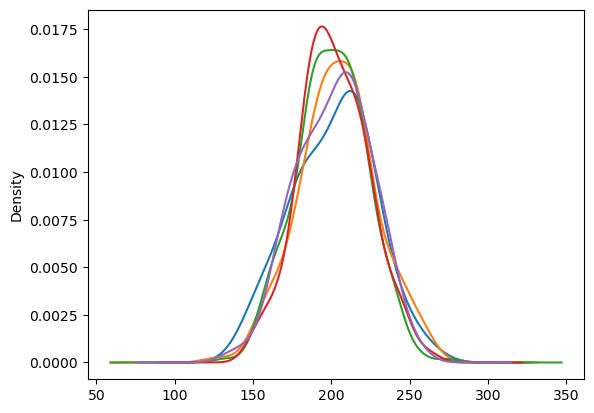

In [258]:
m=S.groupby(S.ethnicity)["total_score"].plot(kind='kde')


In [248]:
#Perform ANOVA to test the equality of means.¶

In [261]:
#check for normality
from scipy.stats import shapiro
s_test,s_pvalue=stats.shapiro(S["total_score"])
print("s_test",s_test)
print("pvalue",s_pvalue)
if pvalue > 0.05:
    print("samples follows normal distribution")
else:
    print("samples  do not follow normal distribution")

<IPython.core.display.Javascript object>

s_test 0.9987789508030015
pvalue 0.7411572889706961
samples follows normal distribution


In [264]:
#check for equality of variance
l_stats, l_pvalue=stats.levene(grp_A,grp_B,grp_C,grp_D,grp_E)
print("l_stats",l_stats)
print("l_pvalue",l_pvalue)
if l_pvalue> 0.05:
    print("variances are equal for all samples")
else:
    print("variances are not equal for all samples")

<IPython.core.display.Javascript object>

l_stats 1.8006030590828939
l_pvalue 0.12649444001357793
variances are equal


In [274]:
#the degrees of freedom for treatments (= t-1)

S.ethnicity.unique() 
t=S.ethnicity.nunique()
print("dgrees of freedom",t)


# the degrees of freedom forerror (=N - t) 
N=S.ethnicity.value_counts().sum()
N= N -t
print("degrees of error",N)

dgrees of freedom 5
degrees of error 995


In [276]:
#calculate fstats
f=stats.f.isf(q=0.05,dfn= 4 , dfd= 995)
print("critical value for f-test ",f)

<IPython.core.display.Javascript object>

critical value for f-test  2.3808758069291818


In [279]:
#perform one way annova
ftest,pval=stats.f_oneway(grp_A,grp_B,grp_C,grp_D,grp_E)
print("ftest",ftest)
print("pval",pval)
if pval < 0.05:
    print("reject null")
else:
    print("failed to reject null")

<IPython.core.display.Javascript object>

ftest 0.789109595922189
pval 0.5322937031083035
failed to reject null


We can also use the anova_lm() in statsmodels library to perform ANOVA.

In [280]:
#perform one way annova
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [285]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [289]:
test =ols('total_score ~ Q("ethnicity")', S).fit()
anova_tab=anova_lm(test,typ = 1)

anova_tab

,df,sum_sq,mean_sq,F,PR(>F)
"Q(""ethnicity"")",4.0,1699.671655,424.917914,0.78911,0.532294
Residual,995.0,535785.303345,538.477692,NaN,NaN


The above output shows that the test statistic is less than 2.3809 and the p-value is greater than 0.05. Thus we fail to reject (i.e. accept) the null hypothesis and conclude that the average score of all races/ethnicities is the same.

# 2. Ryan is a production manager at an industry manufacturing alloy seals. They have 4 machines - A, B, C and D. Ryan wants to study whether all the machines have equal efficiency. Ryan collects data of tensile strength from all the 4 machines as given. Test at 5% level of significance.

In [ ]:
h0: the  average tensile strength  for all the machines are same
h1:the  average tensile strength for atleast on emachine is different

In [309]:
# given data
# tensile strength due to machine A
A =[68.7, 75.4, 70.9, 79.1, 78.2]

# tensile strength due to machine B
B =  [62.7, 68.5, 63.1, 62.2, 60.3]

# tensile strength due to machine C
C = [55.9, 56.1, 57.3, 59.2, 50.1]

# tensile strength due to machine D
D = [80.7, 70.3, 80.9, 85.4, 82.3]




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_18528\3543840883.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xa)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

C:\Users\Chidi\AppData\Local\Temp\ipykernel_18528\3543840883.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xc)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

C:\Users\Chidi\AppData\Local\Temp\ipykernel_18528\3543840883.py:24: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xd)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'probability')

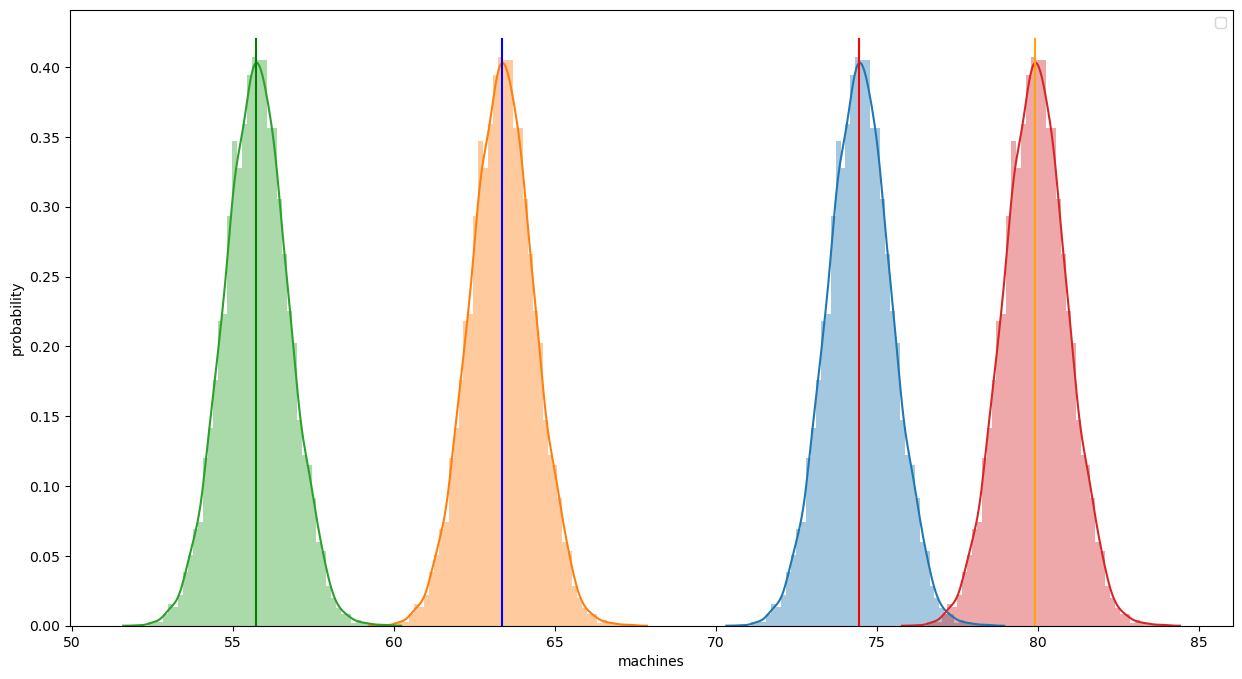

In [310]:
plt.figure(figsize =[15,8])
xa=stats.norm.rvs(loc=np.mean(A),size=10000,random_state=1)
sns.distplot(xa)
x,y = [np.mean(A),np.mean(A)],[0,0.42]
plt.plot(x,y,color="red")
plt.legend()


xb=stats.norm.rvs(loc=np.mean(B),size=10000,random_state=1)
sns.distplot(xb)
x,y = [np.mean(B),np.mean(B)],[0,0.42]
plt.plot(x,y,color="blue")
plt.legend()


xc=stats.norm.rvs(loc=np.mean(C),size=10000,random_state=1)
sns.distplot(xc)
x,y = [np.mean(C),np.mean(C)],[0,0.42]
plt.plot(x,y,color="green")
plt.legend()


xd=stats.norm.rvs(loc=np.mean(D),size=10000,random_state=1)
sns.distplot(xd)
x,y = [np.mean(D),np.mean(D)],[0,0.42]
plt.plot(x,y,color="orange")
plt.legend()

plt.xlabel("machines")
plt.ylabel("probability")

In [2]:


R=pd.DataFrame({
    "machine" : ["machine A","machine B","machine C","machine D"] *5,
    "strength" : [68.7,62.7,55.9,80.7,75.4,68.5,56.1,70.3,70.9,63.1,57.3,80.9,79.1,62.2,59.2,85.4,78.2,60.3,50.1,82.3]
})
R

<IPython.core.display.Javascript object>

,machine,strength
0,machine A,68.7
1,machine B,62.7
2,machine C,55.9
3,machine D,80.7
4,machine A,75.4
5,machine B,68.5
6,machine C,56.1
7,machine D,70.3
8,machine A,70.9
9,machine B,63.1


In [3]:
#check for normality test
from scipy.stats  import shapiro
s_stats,s_pval=stats.shapiro(R.strength)
print("s_stats",s_stats)
print("s_pval",s_pval)
if s_pval > 0.05:
    print("sample follows normal distribution")
else:
    print("sample does not follows normal distribution")

<IPython.core.display.Javascript object>

s_stats 0.950333867026685
s_pval 0.37218602890291447
sample follows normal distribution


In [14]:
#check for equality variance test
macA=R [  ( R['machine']== 'machine A'   ) ]["strength"]
macB=R [  ( R['machine']== 'machine B'   ) ]["strength"]
macC=R [  ( R['machine']== 'machine C'   ) ]["strength"]
macD=R [  ( R['machine']== 'machine D'   ) ]["strength"]




3     80.7
7     70.3
11    80.9
15    85.4
19    82.3
Name: strength, dtype: float64

In [15]:
l_stats,l_pval=stats.levene(macA,macB,macC,macD)
print("l_pval",l_pval)
if l_pval > 0.05:
    print(" population variances are equal for all samples")
else:
    print(" population variances are not equal for all samples")

<IPython.core.display.Javascript object>

l_pval 0.7570021212992085
 population variances are equal for all samples


In [30]:
#degree of freedom

t = R.machine.nunique()  
print('degree of freedom',t)



degree of freedom 4


In [31]:
#degree of error 
N= len(R) 
print("degree of error ",N - t)

degree of error  16


In [34]:
# calculate the F-value for 95% of confidence level
# use 'stats.f.isf()' to find the F-value corresponding to the upper tail probability 'q'
# pass the value of 'alpha' to the parameter 'q', here alpha = 0.05
# pass the degrees of freedom (= 3) to the parameter 'dfn' 
# pass the degrees of freedom (= 16) to the parameter 'dfd' 
f=stats.f.isf(q=0.05,dfn=3,dfd=16)
print("critical value for f test",f)

<IPython.core.display.Javascript object>

critical value for f test 3.238871517453585


In [41]:
#h0: the  average tensile strength  for all the machines are same
#h1:the  average tensile strength for atleast on emachine is different
fstats,pvalue=stats.f_oneway(macA,macB,macC,macD)
print("fstats",fstats)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject null.the  average tensile strength for atleast on emachine is different")
else:
    print("failed to reject null.the  average tensile strength  for all the machines are same")


<IPython.core.display.Javascript object>

fstats 32.03072350199285
pvalue 5.375613532781072e-07
reject null.the  average tensile strength for atleast on emachine is different


# Post-hoc Analysis

If one-way ANOVA rejects the null hypothesis; we conclude that at least one treatment has a different mean. The test does not distinguish a treatment with the different average value. The post-hoc test or `multi comparison test` is used to identify such treatment(s).

In this section, we study the `Tukey's HSD` test. The test calculates the mean difference for each pair of treatments and returns the pair(s) with different average. 

The test statistic of Tukey's HSD test is given as:
<p style='text-indent:28em'> <strong> $T_{\alpha} = q_{{\alpha},(t , f)} \sqrt{\frac{MSE}{n}} $</strong></p>

The value of $q_{{\alpha},(t , f)}$ is obtained from the tukey table.<br>
Where,<br>
t: Number of treatments<br>
f: degrees of freedom for error ($df_{e}$)<br>
MSE: Mean error sum of squares (= $\frac{ESS}{df_{e}}$ = $\sum_{i}^{t}\sum_{j}^{n_{i}}{(x_{ij} - \bar{x_{i}}.)}^{2}$)<br>
n: Number of observations in a treatment

This test is efficient when the sample size for each treatment is equal. If the sample size is not equal fo each treatment then we can use the `Scheffe test`. The `scikit_posthocs.posthoc_scheffe()` can be used to perform the test.

# 1. Ryan is a production manager at an industry manufacturing alloy seals. They have 4 machines - A, B, C and D. Ryan wants to study whether all the machines have equal efficiency. Ryan collects data of tensile strength from all the 4 machines as given. Perform the post-hoc test to find out which machine has a different average. Test at 5% level of significance.

In [43]:
# create a dataframe using a dictionary from given data
d = pd.DataFrame(data = {'machine': ['machine_A','machine_B','machine_C','machine_D']*5, 
                                  'strength': [68.7, 62.7, 55.9, 80.7, 75.4, 68.5, 56.1, 70.3, 70.9, 63.1, 57.3, 80.9, 79.1, 
 
                                               62.2, 59.2, 85.4, 78.2, 60.3, 50.1, 82.3]})

<IPython.core.display.Javascript object>

In [44]:
d

,machine,strength
0,machine_A,68.7
1,machine_B,62.7
2,machine_C,55.9
3,machine_D,80.7
4,machine_A,75.4
5,machine_B,68.5
6,machine_C,56.1
7,machine_D,70.3
8,machine_A,70.9
9,machine_B,63.1


In [48]:
import statsmodels.stats.multicomp  as mc
from  statsmodels.stats.multicomp import pairwise_tukeyhsd
# perform tukey's range test to compare the mean efficiency for pair of machines
# pass the tensile strength to the parameter, 'data'
# pass the name of the machine to the parameter, 'groups'
comp = mc.MultiComparison(data = df_machine['strength'], groups = df_machine['machine'])

# tukey's range test
post_hoc = comp.tukeyhsd()

# print the summary table
post_hoc.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
machine_A,machine_B,-11.1,0.0044,-18.8836,-3.3164,True
machine_A,machine_C,-18.74,0.0,-26.5236,-10.9564,True
machine_A,machine_D,5.46,0.2264,-2.3236,13.2436,False
machine_B,machine_C,-7.64,0.0553,-15.4236,0.1436,False
machine_B,machine_D,16.56,0.0001,8.7764,24.3436,True
machine_C,machine_D,24.2,0.0,16.4164,31.9836,True


In [53]:
import statsmodels.stats.multicomp as mc
from statsmodels.stats.multicomp import pairwise_tukeyhsd

comp=mc.MultiComparison(data= d['strength'] , groups = d['machine'])
postdoc=comp.tukeyhsd()
postdoc.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
machine_A,machine_B,-11.1,0.0044,-18.8836,-3.3164,True
machine_A,machine_C,-18.74,0.0,-26.5236,-10.9564,True
machine_A,machine_D,5.46,0.2264,-2.3236,13.2436,False
machine_B,machine_C,-7.64,0.0553,-15.4236,0.1436,False
machine_B,machine_D,16.56,0.0001,8.7764,24.3436,True
machine_C,machine_D,24.2,0.0,16.4164,31.9836,True


The reject=False for pairs (machine_A, machine_D) and (machine_B, machine_C) denotes that we fail to reject the null hypothesis; and conclude that the average tensile strength due to machine_A and machine_D, machine_B and machine_C is same.

For the pairs (machine_A, machine_B), (machine_A, machine_C), (machine_B, machine_D), and (machine_C, machine_D) the average tensile strength is not the same.

The values in the columns lower and upper represent the lower and upper bound of the 95% confidence interval for the mean difference.

In [54]:
import statsmodels.stats.multicomp as mc
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [58]:
import statsmodels.stats.multicomp as mc
from  statsmodels.stats.multicomp import pairwise_tukeyhsd

comp=mc.MultiComparison(data = d.strength , groups = d.machine)
postdoc=comp.tukeyhsd()
postdoc.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
machine_A,machine_B,-11.1,0.0044,-18.8836,-3.3164,True
machine_A,machine_C,-18.74,0.0,-26.5236,-10.9564,True
machine_A,machine_D,5.46,0.2264,-2.3236,13.2436,False
machine_B,machine_C,-7.64,0.0553,-15.4236,0.1436,False
machine_B,machine_D,16.56,0.0001,8.7764,24.3436,True
machine_C,machine_D,24.2,0.0,16.4164,31.9836,True


# session 7   chisquare 

It is a non-parametric test. `Non-parametric tests` do not require any assumptions on the parameter of the population from which the sample is taken. These tests can be applied to the ordinal/ nominal data. A non-parametric test can be performed on the data containing outliers.

The chi-square test statistic follows a Chi-square ($\chi^{2}$) distribution under the null hypothesis. It can be used to check the relationship between the categorical variables. 

Let us calculate the right-tailed $\chi^{2}$ values for different levels of significance ($\alpha$).

Let us study the following tests:<br>
$\bullet$ Chi-square test for goodness of fit<br>
$\bullet$ Chi-square test for independence<br>
$\bullet$ Chi-square test for equality of variance

# Chi-Square Test for Goodness of Fit

This test is used to compare the distribution of the categorical data with the expected distribution. 

<p style='text-indent:6em'> <strong> $H_{0}$: There is no significant difference between the observed and expected frequencies from the expected distribution</strong></p>
<p style='text-indent:6em'> <strong> $H_{1}$: There is a significant difference between the observed and expected frequencies from the expected distribution</strong></p>

The test statistic is given as:
<p style='text-indent:25em'> <strong> $\chi^{2} = \sum_{i = 1}^{k}\frac{O_{i}^{2}}{E_{i}} - N$</strong></p>

Where, <br>
$O_{i}$: Observed frequency for category i <br>
$E_{i}$: Expected frequency for category i<br>
$N$: Total number of observations

Under $H_{0}$, the test statistic follows a chi-square distribution with $(k - p - 1)$ degrees of freedom, where k is the number class frequencies and p is the number of estimated parameters. 

**Note:** All the expected frequencies should be greater than or equal to 5. If not, add the classes such that each class will have a frequency greater than or equal to 5.

# 1. Check whether there is a significant difference between the observed and expected education values or not with 90% confidence.

In [ ]:
h0: There is no significanct difference between the  observed and expected education value
h1: There is  a significanct difference between the  observed and expected education value

Consider the observed values from the performance dataset of students available in the CSV file students_data.csv. Consider the expected values from the demographic data given in the CSV file demographic_data.csv.

In [6]:
students=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\students_data-1.csv')
students.head(2)

,gender,ethnicity,education,lunch,test_prep_course,math_score,reading_score,writing_score,total_score,training_institute
0,female,group B,bachelor's degree,standard,none,89,55,56,200,Nature Learning
1,female,group C,college,standard,completed,55,63,72,190,Nature Learning


In [33]:
demo=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\demographic_data.csv')
demo.head(5)

,education
0,bachelor's degree
1,college
2,high school
3,associate's degree
4,high school


In [13]:
observed=students.education.value_counts()
observed

education
college               225
associate's degree    222
high school           197
Ph.D.                 179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [15]:
expected=demo.education.value_counts()
expected

education
college               1250
associate's degree    1200
high school           1100
Ph.D.                 1050
bachelor's degree      940
master's degree        600
Name: count, dtype: int64

In [17]:
# calculate the expected values for each category
# multiply the count by sample size and divide it by total number of observations in the population
expected_value = expected * len(students) / len(demo)
expected_value

education
college               203.583062
associate's degree    195.439739
high school           179.153094
Ph.D.                 171.009772
bachelor's degree     153.094463
master's degree        97.719870
Name: count, dtype: float64

In [20]:
print("observed",list(observed))
print("expected_value",list(expected_value))

observed [225, 222, 197, 179, 118, 59]
expected_value [203.5830618892508, 195.43973941368077, 179.1530944625407, 171.0097719869707, 153.09446254071662, 97.71986970684038]


In [24]:
#get the critical value
# calculate the χ2-value for 90% of confidence level
# use 'stats.chi2.isf()' to find the χ2-value corresponding to the upper tail probability 'q'
# pass the value of 'alpha' to the parameter 'q', here alpha = 0.1
# pass the degrees of freedom to the parameter 'df' 
chi2_val=stats.chi2.isf(q=0.1 , df = 5)
print("chi2_val",chi2_val)

<IPython.core.display.Javascript object>

chi2_val 9.236356899781116


In [32]:
# use the 'chisquare()' to perform the goodness of fit test
# the function returns the test statistic value and corresponding p-value
# pass the observed values to the parameter, 'f_obs'
# pass the expected values to the parameter, 'f_exp'



#h0: There is no significanct difference between the  observed and expected education value
#h1: There is  a significanct difference between the  observed and expected education value


from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

c_stats, pvalue=chisquare(f_obs = list(observed) ,  f_exp = list(expected_value))
print("c_stats",c_stats)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject null.There is  a significanct difference between the  observed and expected education value")
else:
    print("failed to reject null.There is no significanct difference between the  observed and expected education value")

c_stats 31.400760035000467
pvalue 7.8061673788274e-06
reject null.There is  a significanct difference between the  observed and expected education value


# 2. At an emporium, the manager is interested in knowing the age group which visits the mall during the day. He defines categories as - children, teenagers, adults and senior citizens. He plans to have his inventory of goods accordingly. He claims that out of all the people who visited 5% are children, 38% are teenagers, 2% are senior citizens are remaining are adults. From a sample of 180 people, it was seen that 25 were children, 50 were teenagers, 90 were adults and 15 were senior citizens. Test the manager’s claim at a 95% confidence level.

In [ ]:
H0:manager claim is wrong
H1:manger claim is right

In [35]:
# get the critical value 
c_val=stats.chi2.isf(q=0.05,df= 3)
print("critical value for chisquare test",c_val)

<IPython.core.display.Javascript object>

critical value for chisquare test 7.814727903251178


In [36]:
obs=[ 25 , 50 , 90, 15]
exp = [ 0.05 , 0.38 ,0.55, 0.02]

In [38]:
# get critical value
from scipy.stats import chi2
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
critical_value=stats.chi2.isf(q=0.05,df=3)
print("critical value",critical_value)

<IPython.core.display.Javascript object>

critical value 7.814727903251178


In [68]:
#get test stastistic , pvalue
obs=[ 25 , 50 , 90, 15]
exp_count = [ 0.05 , 0.38 ,0.55, 0.02]
exp_val = np.round( (np.array (exp_count) *180),1)
exp_val

array([ 9. , 68.4, 99. ,  3.6])

In [73]:
# given observed values
observed_value = [25, 50, 90, 15]

# expected count 
exp_count = [0.05, 0.38, 0.55, 0.02]

# calculate the expected values for each category
# expected_value = (np.array(exp_count) * 180) 
expected_value = [9, 68, 99, 4]




#H0:manager claim is right
#H1:manger claim iswrong


stats,pvalue=chisquare(f_obs=np.array(obs) , f_exp=np.array(exp_val))
print("stats",stats)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject nul")
else:
    print("failed to reject null")

stats 70.31233386496544
pvalue 3.659118590746896e-15
reject nul


# Chi-Square Test for Independence

This test is used to test whether the categorical variables are independent or not.

<p style='text-indent:20em'> <strong> $H_{0}$: The variables are independent</strong></p>
<p style='text-indent:20em'> <strong> $H_{1}$: The variables are not independent (i.e. variables are dependent)</strong></p>

Consider a categorical variable `A` with `r` levels and variable `B` with `c` levels. Let us test the independence of variables A and B.

The test statistic is given as:
<p style='text-indent:25em'> <strong> $\chi^{2} = \sum_{i= 1}^{r}\sum_{j = 1}^{c}\frac{O_{ij}^{2}}{E_{ij}} - N$</strong></p>

Where, <br>
$O_{ij}$: Observed frequency for category (i,j) <br>
$E_{ij}$: Expected frequency for category (i,j)<br>
$N$: Total number of observations

Under $H_{0}$, the test statistic follows a chi-square distribution with $(r-1)(c-1)$ degrees of freedom.

# 1. Check if there is any relationship between the gender and education level of students with 95% confidence.¶

Use the performance dataset of students available in the CSV file students_data.csv.

In [76]:
students.head(5)

,gender,ethnicity,education,lunch,test_prep_course,math_score,reading_score,writing_score,total_score,training_institute
0,female,group B,bachelor's degree,standard,none,89,55,56,200,Nature Learning
1,female,group C,college,standard,completed,55,63,72,190,Nature Learning
2,female,group B,master's degree,standard,none,64,71,56,191,Nature Learning
3,male,group A,associate's degree,free/reduced,none,60,99,72,231,Nature Learning
4,male,group C,college,standard,none,75,66,51,192,Nature Learning


In [ ]:
H0:the variables gender and education are  independent
H1:the variables gender and education  are not independent

In [81]:
table=pd.crosstab(students.gender , students.education)
obs=table.values
obs

array([[ 91, 116,  63, 117,  94,  36],
       [ 88, 106,  55, 108, 103,  23]], dtype=int64)

In [86]:
#get critical level
from scipy.stats import chi2
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
critical=stats.chi2.isf(q=0.05,df=5)


print("critical value",critical)

AttributeError: 'numpy.float64' object has no attribute 'chi2'

In [92]:
#get test stats ,pvalue
teststatics , pvalue , degreeoffreedom , expectedarray =chi2_contingency(observed = obs,correction = False)
print("teststatics ",teststatics )
print("pvalue",pvalue)
print("degreeoffreedom",degreeoffreedom)
print("expectedarray",expectedarray)



#H0:the variables gender and education are  independent
#H1:the variables gender and education  are not independent 


if pvalue < 0.05:
    print("reject null.the variables gender and education  are not independent ")
else:
    print("failed to rejct null.the variables gender and education are  independent")

teststatics  3.5267538812534243
pvalue 0.6193433487137843
degreeoffreedom 5
expectedarray [[ 92.543 114.774  61.006 116.325 101.849  30.503]
 [ 86.457 107.226  56.994 108.675  95.151  28.497]]
failed to rejct null.the variables gender and education are  independent


# 2. A study was conducted to test the effect of the malaria parasite - plasmodium falciparum - on heterozygous and homozygous humans. The vaccine was given to a cohort of 252 humans. Test whether the heterozygous humans are better protected than homozygous. Consider 0.05 as a level of significance.

In [ ]:
h0:two variables zygous type and malaria parasite  and  are  independent
h1:two variables zygous type and malaria parasite  and  are not independent

In [93]:
obs_value=np.array([[93, 51], [68, 40]])


In [116]:
#get criticalvalue
from scipy.stats import chi2
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
critical_value=stats.chi2.isf(q=0.05,df=1)
print("critical value",critical_value)

critical value 3.8414588206941285


In [104]:
#get contingency table
from scipy.stats import chi2
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
stats,pvalue,degree_of_freedom,expected_freq=chi2_contingency(observed=obs_value , correction=False)
print("stats",stats)
print("pvalue",pvalue)
print("degree of freedom",degree_of_freedom)
print("expected_freq",expected_freq)


#h0:two variables zygous type and malaria parasite  and  are  independent
#h1:two variables zygous type and malaria parasite  and  are not independent
if pvalue < 0.05:
    print("reject null.two variables zygous type and malaria parasite    are not independent")
else:
    print("failed to reject null.two variables zygous type and malaria parasite   are  independent")

stats 0.07023411371237459
pvalue 0.790996215494177
degree of freedom 1
expected_freq [[92. 52.]
 [69. 39.]]
failed to reject null.two variables zygous type and malaria parasite   are  independent


# Chi-Square Test for Equality of Variance

This test is used to test whether the population variance ($\sigma^{2}$) is equal to a specific value ($\sigma_{0}^{2}$). Consider that the population mean ($\mu$) is known.

<p style='text-indent:20em'> <strong> $H_{0}$: $\sigma^{2} = \sigma^{2}_{0}$ or $\sigma^{2} \geq \sigma^{2}_{0}$ or $\sigma^{2} \leq \sigma^{2}_{0}$  </strong></p>
<p style='text-indent:20em'> <strong> $H_{1}$: $\sigma^{2} \neq \sigma^{2}_{0}$ or $\sigma^{2} < \sigma^{2}_{0}$ or $\sigma^{2} > \sigma^{2}_{0}$  </strong></p>

The test statistic is given as:

 

Where,
: Population mean
: Sample size

Under 
, the test statistic follows a chi-square distribution with 
 degrees of freedom.

If the population mean (
) is unknown, use sample mean (
) instead of 
. In this case, the test statistic follows a chi-square distribution with 
 degrees of freedom.

The test statistic is given as:
<p style='text-indent:25em'> <strong> $\chi^{2} = \frac{\sum_{i= 1}^{n}(x_{i} - \mu)^{2}}{\sigma_{0}^{2}}$</strong></p>

Where, <br>
$\mu$: Population mean<br>
$n$: Sample size

Under $H_{0}$, the test statistic follows a chi-square distribution with $n$ degrees of freedom.

If the population mean ($\mu$) is unknown, use sample mean ($\bar{x}$) instead of $\mu$. In this case, the test statistic follows a chi-square distribution with $n-1$ degrees of freedom.

# 1. The state board of studies has a record of marks for all the students. The committee of basic sciences wants to check if the variance in the mathematics score is 130 or not. A sample of 55 students is collected from two different institutes. Perform a two-tailed chi-square test with a 5% level of significance.

Use the dataset of students available in the CSV file chisq_var.csv.

In [108]:
board=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\chisq_var.csv')
board.head(5)

,gender,ethnicity,education,lunch,test_prep_course,math_score,reading_score,writing_score,total_score,training_institute
0,female,group C,associate's degree,free/reduced,none,76,65,80,221,Nature Learning
1,male,group D,high school,standard,none,63,71,51,185,Nature Learning
2,male,group D,college,standard,none,90,62,77,229,Nature Learning
3,female,group C,Ph.D.,standard,none,68,60,84,212,Nature Learning
4,male,group D,bachelor's degree,free/reduced,completed,66,91,67,224,Nature Learning


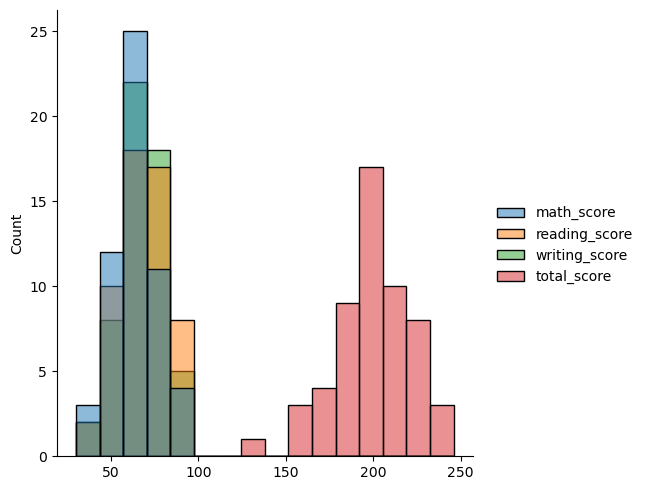

In [119]:
sns.displot(board)

In [ ]:
h0:variance  in mathscore= 130
h1:variance in mathscore != 130

In [109]:
hypo_var = 130
sample_size = len(board)
sample_mean = np.mean(board.math_score)
degree_of_freedom =  sample_size - 1

In [122]:
#get critical values
import scipy.stats
chi2_val_left =stats.chi2.ppf(q=0.05 / 2,df = 54)
print("critical value",chi2_val_left )

critical value 35.58634026352955


In [125]:
chi2_val_right=stats.chi2.ppf(q= (1- 0.05  /2 ),df=54)
print("critical value",chi2_val_right)

critical value 76.19204816624999


The test statistic is given as:
<p style='text-indent:25em'> <strong> $\chi^{2} = \frac{\sum_{i= 1}^{n}(x_{i} - \mu)^{2}}{\sigma_{0}^{2}}$</strong></p>

Where, <br>
$\mu$: Population mean<br>
$n$: Sample size

Under $H_{0}$, the test statistic follows a chi-square distribution with $n$ degrees of freedom.

If the population mean ($\mu$) is unknown, use sample mean ($\bar{x}$) instead of $\mu$. In this case, the test statistic follows a chi-square distribution with $n-1$ degrees of freedom.

In [129]:
#calculate the test statstic
chi_test = np.sum((board.math_score - sample_mean)**2)  / hypo_var
print("chi_test",chi_test)

chi_test 59.87636363636363


In [135]:
#get pvalue


#h0:variance  in mathscore= 130
#h1:variance in mathscore != 130   


pvalue=stats.chi2.sf(chi_test ,df=54)
print("pvalue",pvalue)
if pvalue < 0.05:
    print("reject null.variance in mathscore != 130 ")
else:
    print("failed to reject null.variance  in mathscore= 130")


pvalue 0.27099758895862275
failed to reject null.variance  in mathscore= 130


# 2. At a dairy, the milk is usually supplied in bottles. The manager does not want to exceed the variance of litres of milk cans to 0.26 squarelitres. Some of the following data gives the litres of milk in the cans. Write the null and the alternative hypothesis. Test whether the variance of litres of milk cans is more than 0.26 squarelitres at 5% level of significance.

In [ ]:
h0:variance of litres of milk cans <= 0.26

h1:variance of litres of milk cans > 0.26


In [139]:
milk_lit = np.array([1.5, 1.3, 1.5, 1.5, 1.4, 1.7, 1.6, 1.2])
sample_mean=np.mean(milk_lit)
n = len(milk_lit)
hypo_variance=0.26


In [147]:
#get critical value for rigth tail 
chi2_val=stats.chi2.isf(q= ( 1 - 0.05  )  ,df=n-1)
print("chi2_val",chi2_val)

chi2_val 2.167349909298058


In [145]:
#get chi2 test
chi2_test=np.sum((milk_lit - sample_mean) ** 2) / hypo_variance
print("chi2_test",chi2_test)

chi2_test 0.6875


In [151]:
#get pvalue
#h0:variance of litres of milk cans <= 0.26

#h1:variance of litres of milk cans > 0.26



pval = stats.chi2.sf(chi2_test, df= n -1)
print("pval",pval)
if pval < 0.05:
    print("reject null.variance of litres of milk cans > 0.26")
else:
    print("failed to reject null,variance of litres of milk cans <= 0.26")

pval 0.998429948137378
failed to reject null,variance of litres of milk cans <= 0.26


In [115]:
# import 'pandas' 
import pandas as pd 

# import 'numpy' 
import numpy as np

# import subpackage of matplotlib
import matplotlib.pyplot as plt

# import 'seaborn'
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# import 'stats' package from scipy library
from scipy import stats

# import the functions to perform Chi-square tests
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

# function to perform post-hoc test
import statsmodels.stats.multicomp as mc



In [181]:
from scipy.stats import chi2
from scipy.stats import  chisquare
from scipy.stats import chi2_contingency

In [154]:
obs=np.array([22,20,18,25,15])
exp=np.array([1/5,1/5,1/5,1/5,1/5])*100

In [ ]:
#h0 : candies are evenly diatributed amoung 5 flavors
#h1: candies are not evenly distributed among 5 flavours

In [156]:
#get critical value
chi2_val=stats.chi2.ppf(q=0.05,df=4)
print("chi2_val",chi2_val)

chi2_val 0.7107230213973239


In [160]:
#chisquare stats
chisquarestats=np.sum((obs - exp )** 2)  / exp
print("chisquarestats",chisquarestats)

chisquarestats [2.9 2.9 2.9 2.9 2.9]


In [166]:
#get pvalue
stats,pvalue=stats.chisquare(chisquarestats)
if pvalue==0.05:
    print("reject null")
else:
    print("faild to reject null")

faild to reject null


chisquare test of independance

In [ ]:
h0: music and gender are independent
h1: music and gender are not independent


In [168]:
observed = np.array([[30, 40, 50],[20,30,30]])

In [175]:
rows=observed.sum(axis=1)
cols=observed.sum(axis=0)
total = observed.sum()

In [176]:
expected = np.outer(rows ,cols) / total

In [179]:
chi_square_stat = np.sum( (observed - expected ) ** 2)  / expected
print("chi_square_stat",chi_square_stat)

chi_square_stat [[0.53333333 0.38095238 0.33333333]
 [0.8        0.57142857 0.5       ]]


In [180]:
degrees_of_freedom=observed.shape[0] - 1 * observed.shape[1] - 1
df=degrees_of_freedom

In [183]:
#get critical value
critical_value = stats.chi2.ppf(q=0.95,df)


SyntaxError: positional argument follows keyword argument (1866148637.py, line 2)

In [186]:
#get pvalue
from scipy.stats import chi2
from scipy.stats import  chisquare
from scipy.stats import chi2_contingency
stats.chi2.cdf(chi_square_stat ,df)

AttributeError: 'numpy.float64' object has no attribute 'chi2'